# Classification Modeling Report: Traffic Accidents Injury Severity Prediction

In [ ]:
# Setup cell - run once
# pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.9 MB/s eta 0:00:00


In [ ]:
# Setup cell - run once
# pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 30.3 MB/s eta 0:00:00


In [ ]:
# Setup cell - run once
# pip install optuna-integration[lightgbm]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 9.3 MB/s eta 0:00:00


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt import gp_minimize

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score,
    precision_score, recall_score, roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support, make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import label_binarize

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful!")

All imports successful!


## 1 Dataset Exploration

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fars.csv')

### 1.1 Dataset Overview

The FARS (Fatality Analysis Reporting System) dataset contains records of US road traffic accidents with injury severity as the prediction target.

In [23]:
# ----------------------------------------------------------
# 1.1 DATASET OVERVIEW
# ----------------------------------------------------------
print("\n" + "-"*50)
print("1.1 DATASET OVERVIEW")
print("-"*50)
print(f"Shape: {df_raw.shape}")
print(f"\nColumn Types:\n{df_raw.dtypes.value_counts()}")
display(df_raw.head()) if 'display' in dir() else print(df_raw.head())


--------------------------------------------------
1.1 DATASET OVERVIEW
--------------------------------------------------
Shape: (100968, 30)

Column Types:
object    25
int64      5
Name: count, dtype: int64
  CASE_STATE  AGE     SEX                                PERSON_TYPE  \
0    Alabama   34    Male                                     Driver   
1    Alabama   20    Male                                     Driver   
2    Alabama   43    Male                                     Driver   
3    Alabama   38  Female  Passenger_of_a_Motor_Vehicle_in_Transport   
4    Alabama   50    Male                                     Driver   

                        SEATING_POSITION      RESTRAINT_SYSTEM-USE  \
0  Front_Seat_-_Left_Side_(Drivers_Side)  None_Used/Not_Applicable   
1  Front_Seat_-_Left_Side_(Drivers_Side)  None_Used/Not_Applicable   
2  Front_Seat_-_Left_Side_(Drivers_Side)     Lap_and_Shoulder_Belt   
3                Front_Seat_-_Right_Side     Lap_and_Shoulder_Belt   
4  Fro

### 1.2 Target Variable Analysis

In [24]:
# ----------------------------------------------------------
# 1.2 TARGET VARIABLE
# ----------------------------------------------------------
print("\n" + "-"*50)
print("1.2 TARGET VARIABLE: INJURY_SEVERITY")
print("-"*50)

target_counts = df_raw['INJURY_SEVERITY'].value_counts()
target_pct = (target_counts / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct}))


--------------------------------------------------
1.2 TARGET VARIABLE: INJURY_SEVERITY
--------------------------------------------------
                                Count  Percentage
INJURY_SEVERITY                                  
Fatal_Injury                    42116       41.71
No_Injury                       20007       19.82
Incapaciting_Injury             15072       14.93
Nonincapaciting_Evident_Injury  13890       13.76
Possible_Injury                  8674        8.59
Unknown                           901        0.89
Injured_Severity_Unknown          299        0.30
Died_Prior_to_Accident              9        0.01


**Key observations:**
- Fatal_Injury dominates at 41.7%, creating class imbalance
- Three classes represent <1% of data, requiring consolidation
- Unknown/ambiguous categories should be removed for reliable modeling

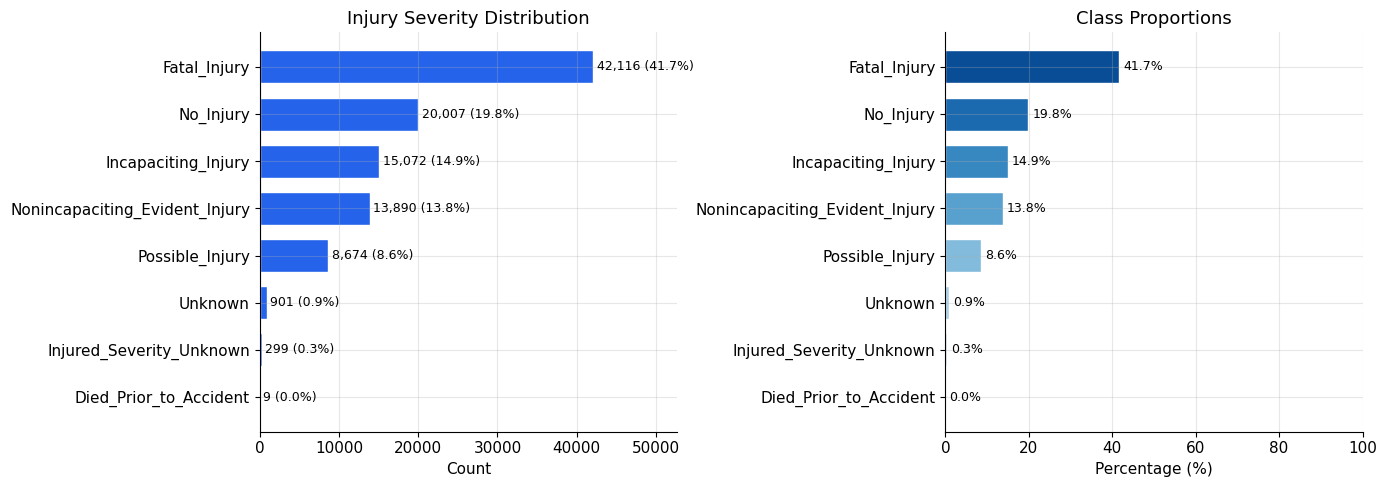


--------------------------------------------------
2.1.3. MISSING VALUES
--------------------------------------------------
Columns with missing values: 0
Empty DataFrame
Columns: [Missing, Percentage]
Index: []

--------------------------------------------------
2.1.4. FEATURE TYPES
--------------------------------------------------
Numerical: 5 columns
Categorical: 25 columns

Numerical stats:
                                  mean         std  min    max
AGE                          37.106707   22.109641  0.0   99.0
ALCOHOL_TEST_RESULT          68.023116   42.306371  0.0   99.0
DRUG_TEST_RESULTS_(1_of_3)  207.393758  396.194002  0.0  999.0
DRUG_TEST_RESULTS_(2_of_3)  100.089672  295.089512  0.0  999.0
DRUG_TEST_RESULTS_(3_of_3)   95.441556  292.121277  0.0  999.0

--------------------------------------------------
2.1.5. KEY FEATURE DISTRIBUTIONS
--------------------------------------------------


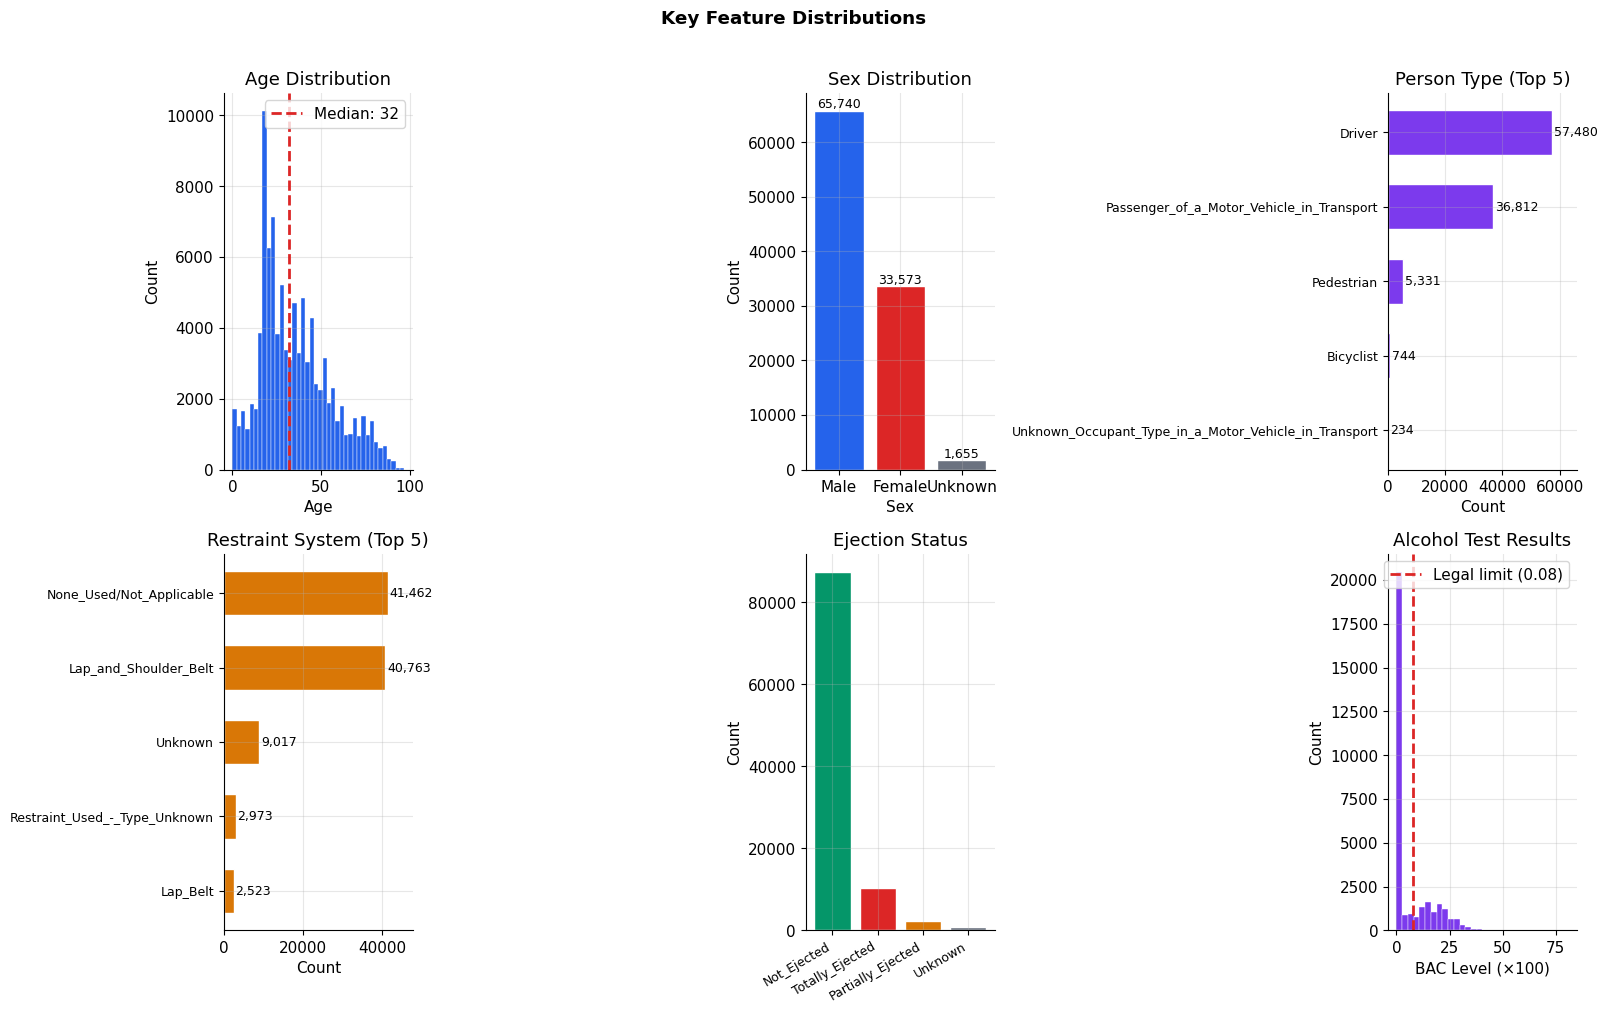


--------------------------------------------------
2.1.6. INJURY SEVERITY BY KEY FEATURES
--------------------------------------------------


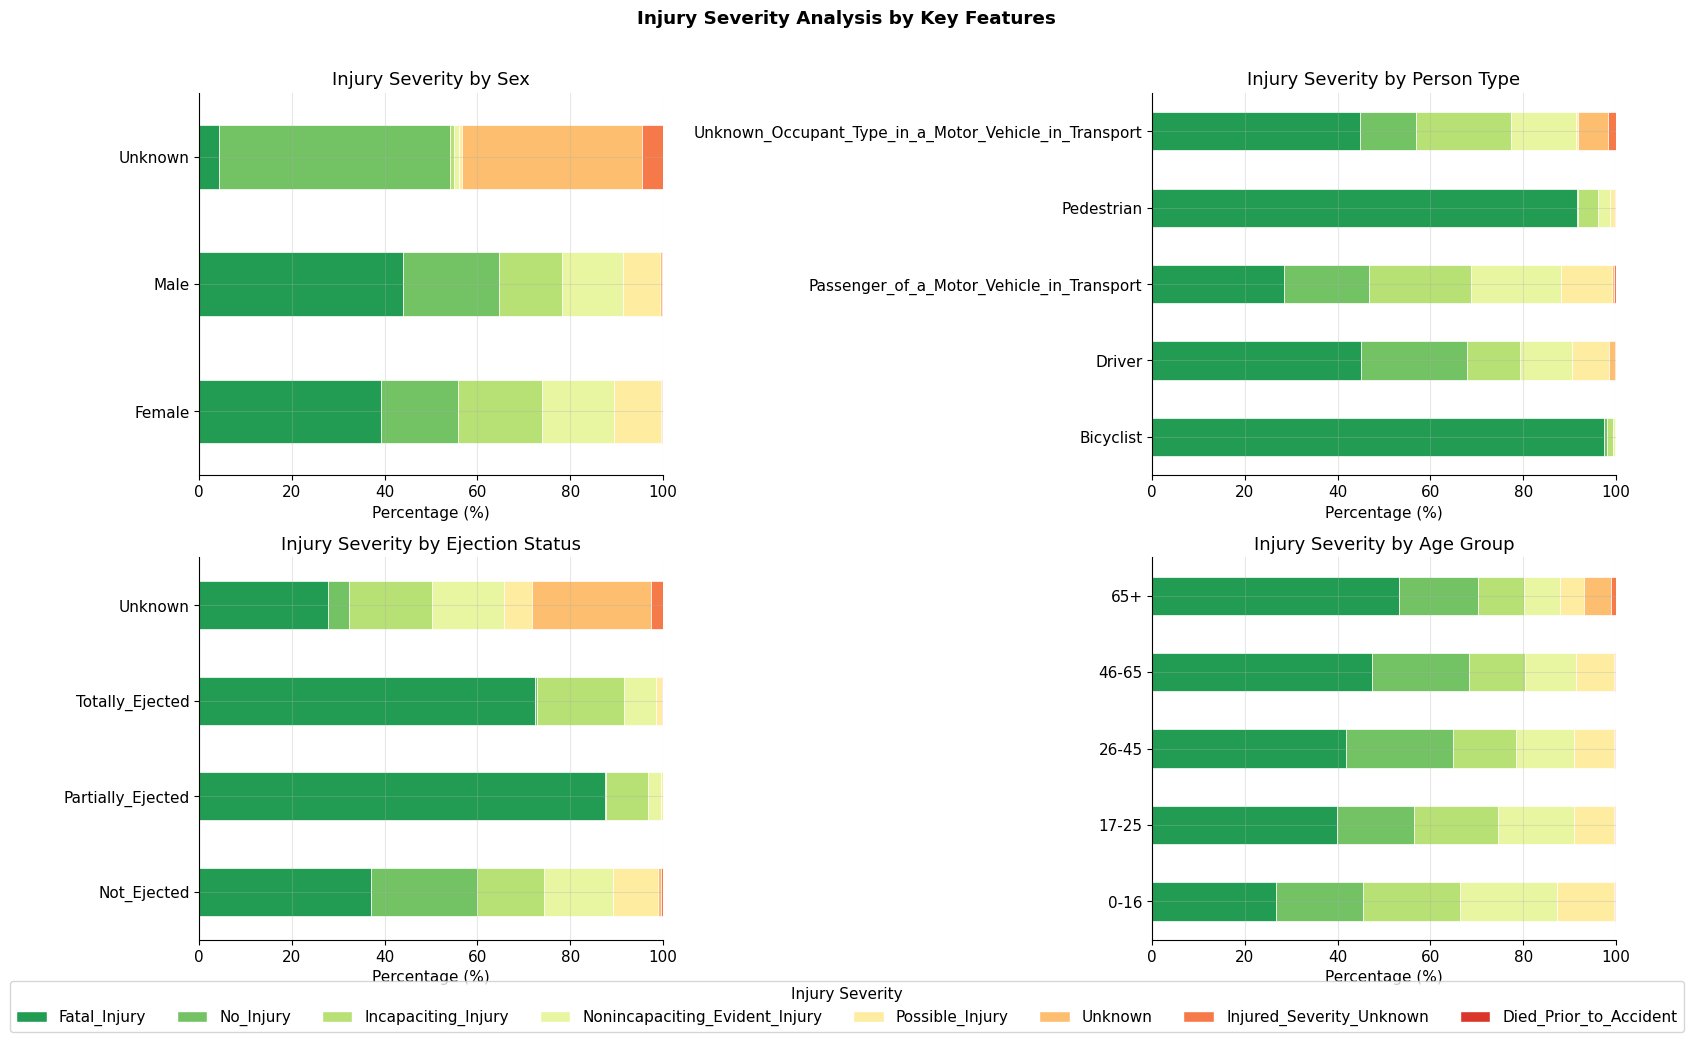

In [25]:
# VISUALISATIONS

# Set clean style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Color palette
C = {'blue': '#2563eb', 'purple': '#7c3aed', 'green': '#059669',
     'orange': '#d97706', 'red': '#dc2626', 'gray': '#6b7280'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].barh(range(len(target_counts)), target_counts.values,
                    color=C['blue'], height=0.7, edgecolor='white')
axes[0].set_yticks(range(len(target_counts)))
axes[0].set_yticklabels(target_counts.index)
axes[0].set_xlabel('Count')
axes[0].set_title('Injury Severity Distribution')
axes[0].invert_yaxis()
axes[0].set_xlim(0, max(target_counts.values) * 1.25)

for i, (bar, count, pct) in enumerate(zip(bars, target_counts.values, target_pct.values)):
    axes[0].text(bar.get_width() + max(target_counts.values)*0.01, i,
                 f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)

# Percentage chart
colors = sns.color_palette("Blues_r", n_colors=len(target_counts))
axes[1].barh(range(len(target_counts)), target_pct.values, color=colors,
             height=0.7, edgecolor='white')
axes[1].set_yticks(range(len(target_counts)))
axes[1].set_yticklabels(target_counts.index)
axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Class Proportions')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 100)

for i, pct in enumerate(target_pct.values):
    axes[1].text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 2.1.3. MISSING VALUES
# ----------------------------------------------------------
print("\n" + "-"*50)
print("2.1.3. MISSING VALUES")
print("-"*50)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.head(15))

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing = missing_df.head(12)
    bars = ax.barh(range(len(top_missing)), top_missing['Percentage'].values,
                   color=C['red'], alpha=0.8, height=0.7)
    ax.set_yticks(range(len(top_missing)))
    ax.set_yticklabels(top_missing.index)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Top Columns with Missing Values')
    ax.invert_yaxis()
    ax.set_xlim(0, max(top_missing['Percentage'].values) * 1.2)

    for i, (pct, cnt) in enumerate(zip(top_missing['Percentage'], top_missing['Missing'])):
        ax.text(pct + 0.3, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# 2.1.4. NUMERICAL & CATEGORICAL FEATURES
# ----------------------------------------------------------
print("\n" + "-"*50)
print("2.1.4. FEATURE TYPES")
print("-"*50)

numerical_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical: {len(numerical_cols)} columns")
print(f"Categorical: {len(categorical_cols)} columns")
print(f"\nNumerical stats:")
print(df_raw[numerical_cols].describe().T[['mean', 'std', 'min', 'max']])

# ----------------------------------------------------------
# 2.1.5. KEY FEATURE DISTRIBUTIONS
# ----------------------------------------------------------
print("\n" + "-"*50)
print("2.1.5. KEY FEATURE DISTRIBUTIONS")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age
ax = axes[0, 0]
age_valid = df_raw[df_raw['AGE'] < 99]['AGE']
ax.hist(age_valid, bins=40, color=C['blue'], edgecolor='white', linewidth=0.3)
ax.axvline(age_valid.median(), color=C['red'], linestyle='--', lw=2,
           label=f'Median: {age_valid.median():.0f}')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age Distribution')
ax.legend()

# Sex
ax = axes[0, 1]
sex_counts = df_raw['SEX'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values,
              color=[C['blue'], C['red'], C['gray']][:len(sex_counts)], edgecolor='white')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
ax.set_title('Sex Distribution')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Person Type
ax = axes[0, 2]
pt_counts = df_raw['PERSON_TYPE'].value_counts().head(5)
ax.barh(range(len(pt_counts)), pt_counts.values, color=C['purple'], height=0.6, edgecolor='white')
ax.set_yticks(range(len(pt_counts)))
ax.set_yticklabels(pt_counts.index, fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Person Type (Top 5)')
ax.invert_yaxis()
ax.set_xlim(0, max(pt_counts.values) * 1.15)
for i, val in enumerate(pt_counts.values):
    ax.text(val + max(pt_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)

# Restraint System
ax = axes[1, 0]
rest_counts = df_raw['RESTRAINT_SYSTEM-USE'].value_counts().head(5)
ax.barh(range(len(rest_counts)), rest_counts.values, color=C['orange'], height=0.6, edgecolor='white')
ax.set_yticks(range(len(rest_counts)))
ax.set_yticklabels(rest_counts.index, fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Restraint System (Top 5)')
ax.invert_yaxis()
ax.set_xlim(0, max(rest_counts.values) * 1.15)
for i, val in enumerate(rest_counts.values):
    ax.text(val + max(rest_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)

# Ejection
ax = axes[1, 1]
ej_counts = df_raw['EJECTION'].value_counts()
ax.bar(range(len(ej_counts)), ej_counts.values,
       color=[C['green'], C['red'], C['orange'], C['gray']][:len(ej_counts)], edgecolor='white')
ax.set_xticks(range(len(ej_counts)))
ax.set_xticklabels(ej_counts.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Ejection Status')

# Alcohol
ax = axes[1, 2]
alc = df_raw['ALCOHOL_TEST_RESULT']
alc_valid = alc[(alc >= 0) & (alc <= 94)]
ax.hist(alc_valid, bins=30, color=C['purple'], edgecolor='white', linewidth=0.3)
ax.axvline(8, color=C['red'], linestyle='--', lw=2, label='Legal limit (0.08)')
ax.set_xlabel('BAC Level (×100)')
ax.set_ylabel('Count')
ax.set_title('Alcohol Test Results')
ax.legend()

plt.suptitle('Key Feature Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 2.1.6. INJURY SEVERITY BY KEY FEATURES
# ----------------------------------------------------------
print("\n" + "-"*50)
print("2.1.6. INJURY SEVERITY BY KEY FEATURES")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

severity_order = df_raw['INJURY_SEVERITY'].value_counts().index.tolist()
colors = sns.color_palette("RdYlGn_r", n_colors=len(severity_order))

# By Sex
ct = pd.crosstab(df_raw['SEX'], df_raw['INJURY_SEVERITY'], normalize='index') * 100
ct = ct.reindex(columns=severity_order, fill_value=0)
ct.plot(kind='barh', stacked=True, ax=axes[0,0], color=colors, edgecolor='white',
        linewidth=0.5, legend=False)
axes[0,0].set_xlabel('Percentage (%)')
axes[0,0].set_ylabel('')
axes[0,0].set_title('Injury Severity by Sex')
axes[0,0].set_xlim(0, 100)

# By Person Type
top_pt = df_raw['PERSON_TYPE'].value_counts().head(5).index
df_pt = df_raw[df_raw['PERSON_TYPE'].isin(top_pt)]
ct = pd.crosstab(df_pt['PERSON_TYPE'], df_pt['INJURY_SEVERITY'], normalize='index') * 100
ct = ct.reindex(columns=severity_order, fill_value=0)
ct.plot(kind='barh', stacked=True, ax=axes[0,1], color=colors, edgecolor='white',
        linewidth=0.5, legend=False)
axes[0,1].set_xlabel('Percentage (%)')
axes[0,1].set_ylabel('')
axes[0,1].set_title('Injury Severity by Person Type')
axes[0,1].set_xlim(0, 100)

# By Ejection
ct = pd.crosstab(df_raw['EJECTION'], df_raw['INJURY_SEVERITY'], normalize='index') * 100
ct = ct.reindex(columns=severity_order, fill_value=0)
ct.plot(kind='barh', stacked=True, ax=axes[1,0], color=colors, edgecolor='white',
        linewidth=0.5, legend=False)
axes[1,0].set_xlabel('Percentage (%)')
axes[1,0].set_ylabel('')
axes[1,0].set_title('Injury Severity by Ejection Status')
axes[1,0].set_xlim(0, 100)

# By Age Group
df_temp = df_raw.copy()
df_temp['Age_Group'] = pd.cut(df_temp['AGE'], bins=[0, 16, 25, 45, 65, 100],
                               labels=['0-16', '17-25', '26-45', '46-65', '65+'])
ct = pd.crosstab(df_temp['Age_Group'], df_temp['INJURY_SEVERITY'], normalize='index') * 100
ct = ct.reindex(columns=severity_order, fill_value=0)
ct.plot(kind='barh', stacked=True, ax=axes[1,1], color=colors, edgecolor='white',
        linewidth=0.5, legend=False)
axes[1,1].set_xlabel('Percentage (%)')
axes[1,1].set_ylabel('')
axes[1,1].set_title('Injury Severity by Age Group')
axes[1,1].set_xlim(0, 100)

# Shared legend
handles = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white') for c in colors]
fig.legend(handles, severity_order, loc='lower center', ncol=len(severity_order),
           bbox_to_anchor=(0.5, -0.02), title='Injury Severity', frameon=True)

plt.suptitle('Injury Severity Analysis by Key Features', fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

### 1.3 Feature Analysis

- **Numerical features** (5): AGE, ALCOHOL_TEST_RESULT, DRUG_TEST_RESULTS (1-3)

- **Categorical features** (25): Include PERSON_TYPE, SEATING_POSITION, RESTRAINT_SYSTEM-USE, EJECTION, AIR_BAG_AVAILABILITY/DEPLOYMENT, and geographic/demographic variables.

- **Potential data leakage identified:**
  - TAKEN_TO_HOSPITAL: Directly indicates injury occurred
  - RACE, HISPANIC_ORIGIN: Correlate with recording practices rather than causation

### 1.4 Key Relationships Observed

Visual inspection revealed strong associations between injury severity and:
- **Ejection status**: Ejected occupants show dramatically higher fatality rates
- **Restraint use**: Unrestrained occupants have worse outcomes
- **Person type**: Pedestrians and cyclists (vulnerable road users) show different injury patterns
- **Age**: Elderly occupants exhibit higher severity for similar crash conditions

## 2 Methods

### 2.1 Data Preprocessing

##### 2.1.1. Target Variable

These columns were removed because they either reveal outcomes directly or correlate with data collection practices rather than injury causation.
```
Removed: RACE, HISPANIC_ORIGIN, TAKEN_TO_HOSPITAL
```

In [26]:
print("2.1.1. TARGET VARIABLE")

LEAKAGE_COLUMNS = ['RACE', 'HISPANIC_ORIGIN', 'TAKEN_TO_HOSPITAL']
cols_to_drop = [c for c in LEAKAGE_COLUMNS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop, errors='ignore')
print(f"Removed: {cols_to_drop}")

# Clean Target Variable
print("\n" + "-"*50)
print("CLEAN TARGET VARIABLE")
print("-"*50)

df['INJURY_SEVERITY'] = df['INJURY_SEVERITY'].replace('Died_Prior_to_Accident', 'Fatal_Injury')
df = df[~df['INJURY_SEVERITY'].isin(['Injured_Severity_Unknown', 'Unknown'])]
print(f"After cleaning: {df['INJURY_SEVERITY'].value_counts().to_dict()}")

# Create 4-Class Target
print("\n" + "-"*50)
print("CREATE 4-CLASS TARGET")
print("-"*50)

target_mapping = {
    'No_Injury': 'No_Injury',
    'Possible_Injury': 'Minor_Injury',
    'Nonincapaciting_Evident_Injury': 'Minor_Injury',
    'Incapaciting_Injury': 'Severe_Injury',
    'Fatal_Injury': 'Fatal_Injury'
}

df['TARGET'] = df['INJURY_SEVERITY'].map(target_mapping)
df = df[~df['TARGET'].isna()]

print("4-Class Distribution:")
print(df['TARGET'].value_counts())

2.1.1. TARGET VARIABLE
Removed: ['RACE', 'HISPANIC_ORIGIN', 'TAKEN_TO_HOSPITAL']

--------------------------------------------------
CLEAN TARGET VARIABLE
--------------------------------------------------
After cleaning: {'Fatal_Injury': 42125, 'No_Injury': 20007, 'Incapaciting_Injury': 15072, 'Nonincapaciting_Evident_Injury': 13890, 'Possible_Injury': 8674}

--------------------------------------------------
CREATE 4-CLASS TARGET
--------------------------------------------------
4-Class Distribution:
TARGET
Fatal_Injury     42125
Minor_Injury     22564
No_Injury        20007
Severe_Injury    15072
Name: count, dtype: int64


The 8-class target was consolidated into 4 clinically meaningful classes:

| Original Class | Mapped To | Rationale |
|----------------|-----------|-----------|
| Fatal_Injury | Fatal_Injury | Clear outcome |
| Incapacitating_Injury | Severe_Injury | Requires immediate medical attention |
| Nonincapacitating_Evident_Injury | Minor_Injury | Visible but non-critical injury |
| Possible_Injury | Minor_Injury | Suspected minor injury |
| No_Injury | No_Injury | No injury recorded |
| Unknown classes | Removed | Unreliable labels |

#### 2.1.2 Feature Engineering

Extensive domain-driven feature engineering expanded the feature set from 29 raw columns to **115 engineered features**:

In [27]:
# DATA PREPROCESSING - FEATURE ENGINEERING
print("2.1.2 FEATURE ENGINEERING")

def engineer_features(df):
    df = df.copy()

    # OCCUPANT TYPE
    df['is_driver'] = (df['PERSON_TYPE'] == 'Driver').astype(int)
    df['is_passenger'] = (df['PERSON_TYPE'] == 'Passenger_of_a_Motor_Vehicle_in_Transport').astype(int)
    df['is_pedestrian'] = (df['PERSON_TYPE'] == 'Pedestrian').astype(int)
    df['is_cyclist'] = df['PERSON_TYPE'].isin(['Bicyclist', 'Other_Cyclist']).astype(int)
    df['is_other_pedestrian'] = (df['PERSON_TYPE'] == 'Other_Pedestrian').astype(int)
    df['vulnerable_road_user'] = (df['is_pedestrian'] | df['is_cyclist'] | df['is_other_pedestrian']).astype(int)
    df['unknown_occupant'] = df['PERSON_TYPE'].str.contains('Unknown', na=False).astype(int)

    # SEATING POSITION
    seating = df['SEATING_POSITION']

    # Basic position
    df['seat_front'] = seating.str.contains('Front_Seat', na=False).astype(int)
    df['seat_second_row'] = seating.str.contains('Second_Seat', na=False).astype(int)
    df['seat_third_row'] = seating.str.contains('Third_Seat', na=False).astype(int)
    df['seat_rear'] = (df['seat_second_row'] | df['seat_third_row']).astype(int)

    # Side of vehicle
    df['seat_left_side'] = seating.str.contains('Left_Side|Drivers_Side', na=False).astype(int)
    df['seat_right_side'] = seating.str.contains('Right_Side', na=False).astype(int)
    df['seat_middle'] = seating.str.contains('Middle', na=False).astype(int)

    # Risky positions
    df['seat_unenclosed'] = seating.str.contains('unenclosed', na=False).astype(int)
    df['seat_cargo_area'] = seating.str.contains('cargo', na=False).astype(int)
    df['seat_unknown'] = (seating == 'Unknown').astype(int)

    # RESTRAINT SYSTEM
    restraint = df['RESTRAINT_SYSTEM-USE']

    # Proper use
    df['belt_lap_shoulder'] = (restraint == 'Lap_and_Shoulder_Belt').astype(int)
    df['belt_lap_only'] = (restraint == 'Lap_Belt').astype(int)
    df['belt_shoulder_only'] = (restraint == 'Shoulder_Belt').astype(int)
    df['seatbelt_proper'] = (df['belt_lap_shoulder'] | df['belt_lap_only'] | df['belt_shoulder_only']).astype(int)

    # No restraint
    df['no_restraint'] = (restraint == 'None_Used/Not_Applicable').astype(int)

    # Helmets
    df['helmet_motorcycle'] = (restraint == 'Motorcycle_Helmet').astype(int)
    df['helmet_bicycle'] = (restraint == 'Bicycle_Helmet').astype(int)
    df['helmet_used'] = (df['helmet_motorcycle'] | df['helmet_bicycle']).astype(int)

    # Child safety
    df['child_seat_used'] = (restraint == 'Child_Safety_Seat').astype(int)
    df['child_seat_improper'] = (restraint == 'Child_Safety_Seat_Used_Improperly').astype(int)

    # Improper use
    df['restraint_improper'] = restraint.str.contains('Improperly', na=False).astype(int)
    df['restraint_unknown'] = (restraint == 'Unknown').astype(int)

    # EJECTION
    ejection = df['EJECTION']

    df['ejected_total'] = (ejection == 'Totally_Ejected').astype(int)
    df['ejected_partial'] = (ejection == 'Partially_Ejected').astype(int)
    df['ejected_any'] = (df['ejected_total'] | df['ejected_partial']).astype(int)
    df['not_ejected'] = (ejection == 'Not_Ejected').astype(int)

    # EJECTION PATH
    ejection_path = df['EJECTION_PATH']

    df['ejection_windshield'] = (ejection_path == 'Through_Windshield').astype(int)
    df['ejection_side_window'] = (ejection_path == 'Through_Side_Window').astype(int)
    df['ejection_side_door'] = (ejection_path == 'Through_Side_Door_Opening').astype(int)
    df['ejection_roof'] = ejection_path.str.contains('Roof', na=False).astype(int)
    df['ejection_back'] = ejection_path.str.contains('Back', na=False).astype(int)

    # High-energy ejection (through windshield or roof = severe)
    df['ejection_high_energy'] = (df['ejection_windshield'] | df['ejection_roof']).astype(int)

    # EXTRICATION
    df['was_extricated'] = (df['EXTRICATION'] == 'Extricated').astype(int)

    # AIRBAG
    airbag = df['AIR_BAG_AVAILABILITY/DEPLOYMENT']

    # Deployment
    df['airbag_deployed_front'] = (airbag == 'Deployed_Air_Bag_from_Front').astype(int)
    df['airbag_deployed_side'] = (airbag == 'Deployed_Air_Bag_from_Side').astype(int)
    df['airbag_deployed_multiple'] = (airbag == 'Deployed_Air_Bag_Multiple_Directions').astype(int)
    df['airbag_deployed_any'] = airbag.str.contains('Deployed', na=False).astype(int)

    # Available but not deployed (low-speed indicator?)
    df['airbag_available_not_deployed'] = (airbag == 'Air_Bag_Available_but_Not_Deployed_for_this_Seat').astype(int)

    # Not available
    df['airbag_not_available'] = (airbag == 'Air_Bag_Not_Available_for_this_Seat').astype(int)

    # Airbag issues (disabled, removed, etc.)
    df['airbag_issue'] = airbag.isin([
        'Air_Bag_Available_and_Switched_Off',
        'Air_Bag_Disabled_or_Removed',
        'Air_Bag_Previously_Deployed_and_not_Replaced'
    ]).astype(int)

    # AGE
    age = df['AGE']
    df['age_unknown'] = (age == 99).astype(int)
    age_valid = age.where(age != 99, np.nan)

    df['age_infant'] = ((age_valid >= 0) & (age_valid < 2)).astype(float).fillna(0).astype(int)
    df['age_child'] = ((age_valid >= 2) & (age_valid < 16)).astype(float).fillna(0).astype(int)
    df['age_young'] = ((age_valid >= 16) & (age_valid < 25)).astype(float).fillna(0).astype(int)
    df['age_adult'] = ((age_valid >= 25) & (age_valid < 65)).astype(float).fillna(0).astype(int)
    df['age_elderly'] = ((age_valid >= 65) & (age_valid < 80)).astype(float).fillna(0).astype(int)
    df['age_very_elderly'] = (age_valid >= 80).astype(float).fillna(0).astype(int)
    df['age_continuous'] = age_valid.fillna(age_valid.median())

    # SEX
    df['is_male'] = (df['SEX'] == 'Male').astype(int)
    df['is_female'] = (df['SEX'] == 'Female').astype(int)
    df['sex_unknown'] = (df['SEX'] == 'Unknown').astype(int)

    # ALCOHOL
    alcohol = df['ALCOHOL_TEST_RESULT']

    df['alcohol_negative'] = (alcohol == 0).astype(int)
    df['alcohol_over_limit'] = ((alcohol >= 8) & (alcohol <= 94)).astype(int)
    df['alcohol_high'] = ((alcohol >= 15) & (alcohol <= 94)).astype(int)  # Very high BAC
    df['alcohol_not_tested'] = (alcohol == 96).astype(int)
    df['bac_level'] = np.where((alcohol >= 0) & (alcohol <= 94), alcohol / 100, 0)

    df['police_alcohol_yes'] = (df['POLICE_REPORTED_ALCOHOL_INVOLVEMENT'] == 'Yes_(Alcohol_Involved)').astype(int)
    df['police_alcohol_no'] = (df['POLICE_REPORTED_ALCOHOL_INVOLVEMENT'] == 'No_(Alcohol_Not_Involved)').astype(int)

    # Testing method
    df['alcohol_evidential_test'] = (df['METHOD_ALCOHOL_DETERMINATION'] == 'Evidential_Test_(Breath_Blood_Urine)').astype(int)
    df['alcohol_observed'] = (df['METHOD_ALCOHOL_DETERMINATION'] == 'Observed').astype(int)

    # Blood test done
    df['blood_test_done'] = df['ALCOHOL_TEST_TYPE'].isin(['Whole_Blood', 'Blood_Plasma/Serum']).astype(int)

    # DRUGS
    drug1 = df['DRUG_TEST_RESULTS_(1_of_3)']
    drug2 = df['DRUG_TEST_RESULTS_(2_of_3)']
    drug3 = df['DRUG_TEST_RESULTS_(3_of_3)']

    pos1 = ((drug1 >= 100) & (drug1 <= 995)).astype(int)
    pos2 = ((drug2 >= 100) & (drug2 <= 995)).astype(int)
    pos3 = ((drug3 >= 100) & (drug3 <= 995)).astype(int)

    df['drug_positive_1'] = pos1
    df['drug_positive_2'] = pos2
    df['drug_positive_3'] = pos3
    df['any_drug_positive'] = (pos1 | pos2 | pos3).astype(int)
    df['multiple_drugs'] = ((pos1 + pos2 + pos3) >= 2).astype(int)
    df['drug_not_tested'] = ((drug1 == 0) & (drug2 == 0) & (drug3 == 0)).astype(int)

    df['police_drug_yes'] = (df['POLICE-REPORTED_DRUG_INVOLVEMENT'] == 'Drugs_Involved').astype(int)
    df['drug_evidential_test'] = (df['METHOD_OF_DRUG_DETERMINATION'] == 'Evidential_Test_(Blood_Urine)').astype(int)

    # IMPAIRMENT COMBINED
    df['any_impairment'] = (df['alcohol_over_limit'] | df['any_drug_positive']).astype(int)
    df['severe_impairment'] = (df['alcohol_high'] | df['multiple_drugs']).astype(int)
    df['alcohol_and_drugs'] = (df['alcohol_over_limit'] & df['any_drug_positive']).astype(int)

    # NON-MOTORIST LOCATION
    nm_loc = df['NON_MOTORIST_LOCATION']

    # Intersection.vs non-intersection
    df['nm_at_intersection'] = nm_loc.str.contains('Intersection', na=False).astype(int)
    df['nm_not_intersection'] = nm_loc.str.contains('Non-Intersection', na=False).astype(int)

    # Crosswalk status
    df['nm_in_crosswalk'] = nm_loc.str.contains('In_Crosswalk', na=False).astype(int)
    df['nm_no_crosswalk'] = nm_loc.str.contains('Not_in_Crosswalk|not_Available', na=False).astype(int)

    # On roadway (dangerous)
    df['nm_on_roadway'] = nm_loc.str.contains('On_Roadway', na=False).astype(int)
    df['nm_on_shoulder'] = nm_loc.str.contains('Shoulder', na=False).astype(int)
    df['nm_outside_trafficway'] = nm_loc.str.contains('Outside_Trafficway', na=False).astype(int)

    # RELATED FACTORS (NEW - EXPANDED)
    rf1 = df['RELATED_FACTOR_(1)-PERSON_LEVEL'].fillna('')
    rf2 = df['RELATED_FACTOR_(2)-PERSON_LEVEL'].fillna('')
    rf3 = df['RELATED_FACTOR_(3)-PERSON_LEVEL'].fillna('')

    # Combine all factors for searching
    all_factors = rf1 + ' ' + rf2 + ' ' + rf3

    # Pedestrian behaviors
    df['factor_darting'] = all_factors.str.contains('Darting', na=False).astype(int)
    df['factor_not_visible'] = all_factors.str.contains('Not_Visible', na=False).astype(int)
    df['factor_improper_crossing'] = all_factors.str.contains('Improper_Crossing', na=False).astype(int)
    df['factor_in_roadway'] = all_factors.str.contains('in_Roadway|Playing|Working|Sitting|Lying|Standing', na=False).astype(int)

    # Failure behaviors
    df['factor_failure_yield'] = all_factors.str.contains('Failure_to_Yield', na=False).astype(int)
    df['factor_failure_obey'] = all_factors.str.contains('Failure_to_Obey', na=False).astype(int)

    # Attention
    df['factor_inattentive'] = all_factors.str.contains('Inattentive', na=False).astype(int)

    # Has any contributing factor
    df['has_contributing_factor'] = (~rf1.str.contains('Not_Applicable|None', na=True)).astype(int)
    df['has_multiple_factors'] = (
        (~rf1.str.contains('Not_Applicable', na=True)) &
        (~rf2.str.contains('Not_Applicable', na=True))
    ).astype(int)

    # GEOGRAPHY
    state = df['CASE_STATE']

    # Regions
    south = ['Texas', 'Florida', 'Georgia', 'North_Carolina', 'Tennessee', 'Alabama', 'Louisiana', 'South_Carolina', 'Mississippi', 'Arkansas']
    west = ['California', 'Arizona', 'Nevada', 'Colorado', 'Washington', 'Oregon', 'Utah', 'New_Mexico']
    northeast = ['New_York', 'Pennsylvania', 'New_Jersey', 'Massachusetts', 'Connecticut', 'Maryland']
    midwest = ['Illinois', 'Ohio', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri']

    df['region_south'] = state.isin(south).astype(int)
    df['region_west'] = state.isin(west).astype(int)
    df['region_northeast'] = state.isin(northeast).astype(int)
    df['region_midwest'] = state.isin(midwest).astype(int)

    # High-fatality states (top states by fatal crash rate)
    high_fatality = ['Mississippi', 'Wyoming', 'New_Mexico', 'South_Carolina', 'Alabama', 'Montana']
    df['high_fatality_state'] = state.isin(high_fatality).astype(int)

    # COMPOSITE RISK SCORES

    # Protection Score (higher = better protected)
    df['protection_score'] = (
        df['belt_lap_shoulder'] * 2.0 +
        df['belt_lap_only'] * 1.0 +
        df['belt_shoulder_only'] * 1.0 +
        df['helmet_used'] * 1.5 +
        df['child_seat_used'] * 1.5 +
        df['airbag_deployed_any'] * 1.0 +
        df['seat_rear'] * 0.5 +
        df['seat_third_row'] * 0.3
    )

    # Vulnerability Score (higher = more vulnerable)
    df['vulnerability_score'] = (
        df['no_restraint'] * 2.0 +
        df['ejected_total'] * 3.0 +
        df['ejected_partial'] * 2.0 +
        df['ejection_high_energy'] * 1.5 +
        df['vulnerable_road_user'] * 2.0 +
        df['age_very_elderly'] * 1.5 +
        df['age_elderly'] * 1.0 +
        df['age_infant'] * 1.0 +
        df['restraint_improper'] * 1.5 +
        df['seat_unenclosed'] * 1.5 +
        df['child_seat_improper'] * 2.0
    )

    # Impairment Score
    df['impairment_score'] = (
        df['alcohol_over_limit'] * 1.5 +
        df['alcohol_high'] * 1.0 +
        df['any_drug_positive'] * 1.5 +
        df['multiple_drugs'] * 1.0 +
        df['alcohol_and_drugs'] * 1.0
    )

    # Crash Severity Proxy (indicators of serious crash)
    df['crash_severity_proxy'] = (
        df['was_extricated'] * 2.0 +
        df['airbag_deployed_multiple'] * 1.5 +
        df['airbag_deployed_side'] * 0.5 +
        df['blood_test_done'] * 0.5
    )

    # Net Risk Score
    df['net_risk_score'] = (
        df['vulnerability_score'] -
        df['protection_score'] +
        df['impairment_score'] +
        df['crash_severity_proxy']
    )

    # HIGH-RISK COMBINATIONS

    # Ejection + No Restraint
    df['unrestrained_ejected'] = (df['no_restraint'] & df['ejected_any']).astype(int)
    df['unrestrained_windshield'] = (df['no_restraint'] & df['ejection_windshield']).astype(int)

    # Age + Restraint
    df['elderly_unrestrained'] = ((df['age_elderly'] | df['age_very_elderly']) & df['no_restraint']).astype(int)
    df['child_unrestrained'] = (df['age_child'] & df['no_restraint']).astype(int)
    df['infant_improper_seat'] = (df['age_infant'] & df['child_seat_improper']).astype(int)

    # Vulnerable + Impaired
    df['vulnerable_impaired'] = (df['vulnerable_road_user'] & df['any_impairment']).astype(int)
    df['pedestrian_not_visible_impaired'] = (df['is_pedestrian'] & df['factor_not_visible'] & df['any_impairment']).astype(int)

    # Pedestrian risky behavior
    df['pedestrian_risky'] = (
        df['is_pedestrian'] &
        (df['factor_darting'] | df['factor_improper_crossing'] | df['nm_no_crosswalk'])
    ).astype(int)

    # Driver impaired
    df['driver_impaired'] = (df['is_driver'] & df['any_impairment']).astype(int)
    df['driver_severe_impairment'] = (df['is_driver'] & df['severe_impairment']).astype(int)

    # Front seat + no airbag deployed (old car or low speed?)
    df['front_no_airbag'] = (df['seat_front'] & df['airbag_not_available']).astype(int)

    # Extricated + Ejected (very severe)
    df['extricated_and_ejected'] = (df['was_extricated'] & df['ejected_any']).astype(int)

    return df

df = engineer_features(df)
print(f"After feature engineering: {df.shape}")

# Define Feature Columns
FEATURE_COLUMNS = [
    # Occupant Type (7)
    'is_driver', 'is_passenger', 'is_pedestrian', 'is_cyclist',
    'is_other_pedestrian', 'vulnerable_road_user', 'unknown_occupant',

    # Seating Position (10)
    'seat_front', 'seat_second_row', 'seat_third_row', 'seat_rear',
    'seat_left_side', 'seat_right_side', 'seat_middle',
    'seat_unenclosed', 'seat_cargo_area', 'seat_unknown',

    # Restraint System (12)
    'belt_lap_shoulder', 'belt_lap_only', 'belt_shoulder_only', 'seatbelt_proper',
    'no_restraint', 'helmet_motorcycle', 'helmet_bicycle', 'helmet_used',
    'child_seat_used', 'child_seat_improper', 'restraint_improper', 'restraint_unknown',

    # Ejection (10)
    'ejected_total', 'ejected_partial', 'ejected_any', 'not_ejected',
    'ejection_windshield', 'ejection_side_window', 'ejection_side_door',
    'ejection_roof', 'ejection_back', 'ejection_high_energy',

    # Extrication (1)
    'was_extricated',

    # Airbag (7)
    'airbag_deployed_front', 'airbag_deployed_side', 'airbag_deployed_multiple',
    'airbag_deployed_any', 'airbag_available_not_deployed',
    'airbag_not_available', 'airbag_issue',

    # Age (8)
    'age_unknown', 'age_infant', 'age_child', 'age_young',
    'age_adult', 'age_elderly', 'age_very_elderly', 'age_continuous',

    # Sex (3)
    'is_male', 'is_female', 'sex_unknown',

    # Alcohol (10)
    'alcohol_negative', 'alcohol_over_limit', 'alcohol_high',
    'alcohol_not_tested', 'bac_level',
    'police_alcohol_yes', 'police_alcohol_no',
    'alcohol_evidential_test', 'alcohol_observed', 'blood_test_done',

    # Drugs (8)
    'drug_positive_1', 'drug_positive_2', 'drug_positive_3', 'any_drug_positive',
    'multiple_drugs', 'drug_not_tested', 'police_drug_yes', 'drug_evidential_test',

    # Impairment Combined (3)
    'any_impairment', 'severe_impairment', 'alcohol_and_drugs',

    # Non-motorist Location (7)
    'nm_at_intersection', 'nm_not_intersection', 'nm_in_crosswalk',
    'nm_no_crosswalk', 'nm_on_roadway', 'nm_on_shoulder', 'nm_outside_trafficway',

    # Related Factors (9)
    'factor_darting', 'factor_not_visible', 'factor_improper_crossing',
    'factor_in_roadway', 'factor_failure_yield', 'factor_failure_obey',
    'factor_inattentive', 'has_contributing_factor', 'has_multiple_factors',

    # Geography (5)
    'region_south', 'region_west', 'region_northeast', 'region_midwest',
    'high_fatality_state',

    # Composite Scores (5)
    'protection_score', 'vulnerability_score', 'impairment_score',
    'crash_severity_proxy', 'net_risk_score',

    # High-Risk Combinations (12)
    'unrestrained_ejected', 'unrestrained_windshield',
    'elderly_unrestrained', 'child_unrestrained', 'infant_improper_seat',
    'vulnerable_impaired', 'pedestrian_not_visible_impaired', 'pedestrian_risky',
    'driver_impaired', 'driver_severe_impairment',
    'front_no_airbag', 'extricated_and_ejected'
]

print(f"\nTotal features: {len(FEATURE_COLUMNS)}")

# Show comparison
print(f"\n" + "="*50)
print("FEATURE COMPARISON: OLD vs NEW")
print("="*50)
old_features = len(df_raw.columns)
print(f"Old feature count: {old_features}")
print(f"New feature count: {len(FEATURE_COLUMNS)}")
print(f"New features added: {len(FEATURE_COLUMNS) - old_features}")

2.1.2 FEATURE ENGINEERING
After feature engineering: (99768, 145)

Total features: 117

FEATURE COMPARISON: OLD vs NEW
Old feature count: 30
New feature count: 117
New features added: 87


### Feature Engineering Notes

Our feature engineering strategy creates 117 features from 29 raw variables,
organized into categories:

1. **Binary indicators**: Convert categorical values to interpretable flags
2. **Composite scores**: Combine related features (protection_score, vulnerability_score)
3. **Interaction terms**: Capture high-risk combinations (elderly_unrestrained, driver_impaired)
4. **Domain knowledge**: Encode safety research (ejection severity, restraint effectiveness)

This domain-driven approach is preferred over automated feature generation because:
- Features have clinical/safety interpretability
- Reduces risk of data leakage
- Aligns with known injury severity predictors

#### 2.1.3 Train-test split and setup

In [28]:
# TRAIN-TEST SPLIT AND SETUP

print("\n" + "="*70)
print("2.1.3 TRAIN-TEST SPLIT AND SETUP")
print("="*70)

# Define X and y
X = df[FEATURE_COLUMNS].copy()
y = df['TARGET'].copy()

# Encode target
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(f"\nFinal dataset shape: X={X.shape}, y={y_encoded.shape}")
print(f"Classes: {encoder.classes_}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

print(f"\nTrain set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Setup cross-validation
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"\nCross-validation: {N_FOLDS}-fold Stratified K-Fold")

# Define scorer
macro_f1_scorer = make_scorer(f1_score, average='macro')

# Calculate class weights
class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"\nClass weights:")
for i, cls in enumerate(encoder.classes_):
    print(f"  {cls}: {class_weight_dict[i]:.3f}")

# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


2.1.3 TRAIN-TEST SPLIT AND SETUP

Final dataset shape: X=(99768, 117), y=(99768,)
Classes: ['Fatal_Injury' 'Minor_Injury' 'No_Injury' 'Severe_Injury']
Class distribution: [42125 22564 20007 15072]

Train set: 84,802 samples (85.0%)
Test set: 14,966 samples (15.0%)

Cross-validation: 5-fold Stratified K-Fold

Class weights:
  Fatal_Injury: 0.592
  Minor_Injury: 1.105
  No_Injury: 1.247
  Severe_Injury: 1.655


- **Split ratio**: 85% training / 15% test
- **Stratification**: Applied to maintain class proportions
- **Cross-validation**: 5-fold Stratified K-Fold for hyperparameter tuning
- **Final sizes**: 84,802 training samples, 14,966 test samples

#### 2.1.4 Feature selection

Feature importance was evaluated using three methods combined: Logistic Regression coefficients, Decision Tree importance, and Mutual Information scores.

In [29]:
# FEATURE SELECTION (Using Logistic Regression and Decision Tree)

print("\n" + "="*70)
print("2.1.4 FEATURE SELECTION")
print("="*70)

# Model 1: Logistic Regression
print("\nFitting Logistic Regression...")
lr_simple = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_simple.fit(X_train_scaled, y_train)

# LR importance (absolute mean coefficients)
lr_coef_importance = np.abs(lr_simple.coef_).mean(axis=0)
lr_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'lr_importance': lr_coef_importance
})

# Model 2: Decision Tree
print("Fitting Decision Tree...")
dt_simple = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_simple.fit(X_train, y_train)

dt_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'dt_importance': dt_simple.feature_importances_
})

# Mutual Information
print("Calculating Mutual Information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE, n_jobs=-1)
mi_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'mi_importance': mi_scores
})

# Combine importance scores
importance_df = lr_importance.merge(dt_importance, on='feature')
importance_df = importance_df.merge(mi_importance, on='feature')

# Normalize to 0-1
for col in ['lr_importance', 'dt_importance', 'mi_importance']:
    max_val = importance_df[col].max()
    if max_val > 0:
        importance_df[f'{col}_norm'] = importance_df[col] / max_val
    else:
        importance_df[f'{col}_norm'] = 0

# Combined score
importance_df['combined_score'] = (
    importance_df['lr_importance_norm'] +
    importance_df['dt_importance_norm'] +
    importance_df['mi_importance_norm']
) / 3

importance_df = importance_df.sort_values('combined_score', ascending=False)

print("\nTop 15 Features:")
print(importance_df[['feature', 'combined_score']].head(15).to_string(index=False))

sorted_features = importance_df['feature'].tolist()


2.1.4 FEATURE SELECTION

Fitting Logistic Regression...
Fitting Decision Tree...
Calculating Mutual Information...

Top 15 Features:
             feature  combined_score
      net_risk_score        0.839095
crash_severity_proxy        0.613673
 vulnerability_score        0.485646
  alcohol_not_tested        0.425715
         not_ejected        0.421959
     blood_test_done        0.364499
          seat_front        0.348120
        no_restraint        0.306578
      was_extricated        0.295815
       is_pedestrian        0.290909
     driver_impaired        0.282620
      age_continuous        0.282467
vulnerable_road_user        0.281160
     drug_not_tested        0.270741
           bac_level        0.270299


#### 2.1.5 Find the best subset

In [30]:
# FIND THE BEST SUBSET

print("\n" + "-"*50)
print("2.2.5. FIND THE BEST SUBSET")
print("-"*50)

feature_counts = [20, 30, 40, 50, 60, 70, 80, 90, 100, len(FEATURE_COLUMNS)]
results = []

print(f"\n{'Features':<10} {'LR Score':<12} {'DT Score':<12} {'Average':<12}")
print("-" * 46)

for n_features in feature_counts:
    top_n = sorted_features[:n_features]
    X_subset = X_train[top_n]
    X_subset_scaled = scaler.fit_transform(X_subset)

    # LR score
    lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500,
                            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    lr_scores = cross_val_score(lr, X_subset_scaled, y_train, cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

    # DT score
    dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10,
                                class_weight='balanced', random_state=RANDOM_STATE)
    dt_scores = cross_val_score(dt, X_subset, y_train, cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

    avg = (lr_scores.mean() + dt_scores.mean()) / 2
    results.append({'n_features': n_features, 'lr': lr_scores.mean(), 'dt': dt_scores.mean(), 'avg': avg})

    print(f"{n_features:<10} {lr_scores.mean():.4f}       {dt_scores.mean():.4f}       {avg:.4f}")

results_df = pd.DataFrame(results)
optimal_n = int(results_df.loc[results_df['avg'].idxmax(), 'n_features'])

print(f"\nOptimal number of features: {optimal_n}")


--------------------------------------------------
2.2.5. FIND THE BEST SUBSET
--------------------------------------------------

Features   LR Score     DT Score     Average     
----------------------------------------------
20         0.4660       0.4828       0.4744
30         0.4996       0.5037       0.5016
40         0.5081       0.5007       0.5044
50         0.5128       0.4933       0.5030
60         0.5143       0.4961       0.5052
70         0.5146       0.4919       0.5033
80         0.5184       0.4936       0.5060
90         0.5206       0.4944       0.5075
100        0.5189       0.4946       0.5067
117        0.5193       0.4946       0.5070

Optimal number of features: 90



Selected 90 features:
   1. net_risk_score                      (0.8391)
   2. crash_severity_proxy                (0.6137)
   3. vulnerability_score                 (0.4856)
   4. alcohol_not_tested                  (0.4257)
   5. not_ejected                         (0.4220)
   6. blood_test_done                     (0.3645)
   7. seat_front                          (0.3481)
   8. no_restraint                        (0.3066)
   9. was_extricated                      (0.2958)
  10. is_pedestrian                       (0.2909)
  11. driver_impaired                     (0.2826)
  12. age_continuous                      (0.2825)
  13. vulnerable_road_user                (0.2812)
  14. drug_not_tested                     (0.2707)
  15. bac_level                           (0.2703)
  16. nm_at_intersection                  (0.2562)
  17. alcohol_negative                    (0.2325)
  18. pedestrian_risky                    (0.2259)
  19. protection_score                    (0.2135)
  20. un

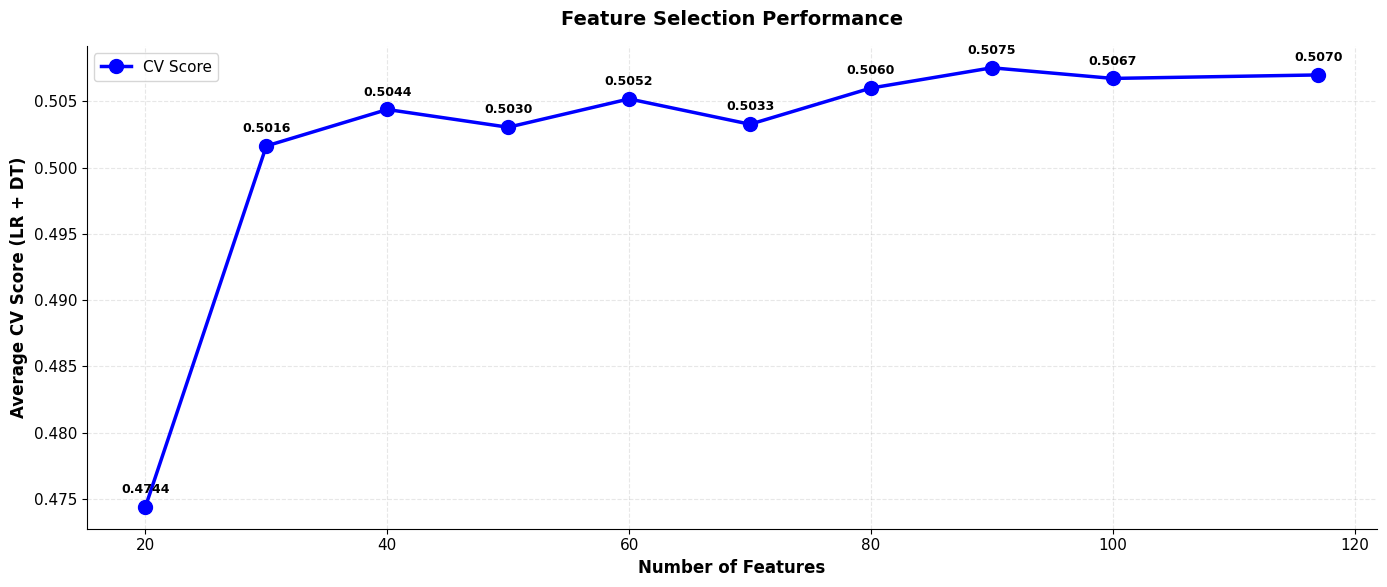

In [31]:
SELECTED_FEATURES = sorted_features[:optimal_n]

print(f"\nSelected {len(SELECTED_FEATURES)} features:")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    score = importance_df[importance_df['feature'] == feat]['combined_score'].values[0]
    print(f"  {i:2d}. {feat:<35} ({score:.4f})")

# Create selected datasets
X_train_selected = X_train[SELECTED_FEATURES]
X_test_selected = X_test[SELECTED_FEATURES]

# Scale for LR
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

print(f"\nFinal shapes:")
print(f"  Original: {X_train.shape} → Selected: {X_train_selected.shape}")
print(f"  Reduction: {len(FEATURE_COLUMNS) - len(SELECTED_FEATURES)} features removed")

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Performance vs Features
line = ax.plot(results_df['n_features'], results_df['avg'], 'b-o',
               markersize=10, linewidth=2.5, label='CV Score')[0]

# Add data labels on each point
for idx, row in results_df.iterrows():
    ax.annotate(f"{row['avg']:.4f}",
                xy=(row['n_features'], row['avg']),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                fontweight='bold')

ax.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Average CV Score (LR + DT)', fontsize=12, fontweight='bold')
ax.set_title('Feature Selection Performance', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Feature Selection Results:**

Performance plateaued after ~30 features, with marginal gains from 30 to 90 features (the highest performance) (0.5016 to 0.5075). Since 90 features achieved the best score and tree-based models handle high-dimensional data efficiently, **all of the top 90 features will be used for final modeling**.

### 2.2 Model Pipelines

Four pipelines were designed with increasing complexity to demonstrate the value of different modeling approaches:

| Pipeline | Model | Justification |
|----------|-------|---------------|
| **1** | Logistic Regression | Linear baseline; fast, interpretable; establishes reference performance |
| **2** | Random Forest | Bagging ensemble; captures non-linear relationships; robust to overfitting |
| **3** | LightGBM | Gradient boosting; sequential error correction; efficient with large datasets |
| **4** | XGBoost OvR | One-vs-Rest strategy; enables class-specific optimization for imbalanced data with Bayesian Optimization method|

#### 2.2.1 PIPELINE 1 - LOGISTIC REGRESSION (Baseline)

**Pipeline 1: Logistic Regression (Baseline)**
- No tuning applied (establishes baseline)
- class_weight='balanced' to address imbalance

In [32]:
# PIPELINE 1 - LOGISTIC REGRESSION (Baseline)

print("\n" + "="*70)
print("2.2.1 PIPELINE 1: LOGISTIC REGRESSION (Baseline)")
print("="*70)

start_time = time.time()

lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training with 5-fold CV...")
lr_cv_scores = cross_val_score(lr_model, X_train_selected_scaled, y_train,
                                cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

print(f"CV Macro-F1 scores: {lr_cv_scores.round(4)}")
print(f"Mean CV Macro-F1: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std()*2:.4f})")

# Train final model
lr_model.fit(X_train_selected_scaled, y_train)
lr_pred = lr_model.predict(X_test_selected_scaled)
lr_proba = lr_model.predict_proba(X_test_selected_scaled)

lr_test_f1 = f1_score(y_test, lr_pred, average='macro')
lr_time = time.time() - start_time

print(f"\nTest Macro-F1: {lr_test_f1:.4f}")
print(f"Time: {lr_time:.1f} seconds")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=encoder.classes_, digits=4))


2.2.1 PIPELINE 1: LOGISTIC REGRESSION (Baseline)
Training with 5-fold CV...
CV Macro-F1 scores: [0.5204 0.5169 0.5248 0.5164 0.5246]
Mean CV Macro-F1: 0.5206 (+/- 0.0072)

Test Macro-F1: 0.5203
Time: 10.4 seconds

Classification Report:
               precision    recall  f1-score   support

 Fatal_Injury     0.8377    0.7148    0.7714      6319
 Minor_Injury     0.4322    0.3486    0.3859      3385
    No_Injury     0.4793    0.6518    0.5524      3001
Severe_Injury     0.3377    0.4126    0.3714      2261

     accuracy                         0.5737     14966
    macro avg     0.5217    0.5320    0.5203     14966
 weighted avg     0.5986    0.5737    0.5799     14966



#### 2.2.2 PIPELINE 2 - RANDOM FOREST (Ensemble + Tuning)

**Pipeline 2: Random Forest**
- Stage 1: RandomizedSearchCV (100 iterations, 5-fold CV)
  - Parameters: n_estimators [150-400], max_depth [10-20], min_samples_split [5-15], min_samples_leaf [1-5]
- Stage 2: Class weight tuning (tested 6 configurations)
  - Result: 'balanced' performed best

In [33]:
# PIPELINE 2 - RANDOM FOREST (with weight balance tuning)

print("\n" + "="*70)
print("2.2.2 PIPELINE 2: RANDOM FOREST (with weight balance tuning)")
print("="*70)

start_time = time.time()

# Stage 1: Standard RandomizedSearchCV
print("Stage 1: RandomizedSearchCV (150 iterations)...")

rf_param_dist = {
    'n_estimators': randint(150, 400),
    'max_depth': randint(10, 25),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=150,
    cv=cv,
    scoring=macro_f1_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_selected, y_train)

stage1_time = time.time() - start_time
print(f"\nStage 1 completed in {stage1_time:.1f} seconds")
print(f"Best CV Macro-F1 (Stage 1): {rf_search.best_score_:.4f}")

print("\nBest Parameters (Stage 1):")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")

# Stage 2: Custom Class Weights Tuning
print("\n" + "-"*40)
print("Stage 2: Class Weight Tuning...")

best_rf_params = rf_search.best_params_.copy()
best_rf_params.pop('class_weight', None)

# Test different class weight combinations
weight_results = []

# Boost minority classes (Minor and Severe)
weight_configs = [
    {0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5},
    {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.0},
    {0: 1.0, 1: 1.5, 2: 0.8, 3: 1.8},
    {0: 0.8, 1: 1.8, 2: 1.0, 3: 1.8},
    {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.5},
    'balanced',
]

print("Testing class weight configurations...")

for weights in weight_configs:
    rf_test = RandomForestClassifier(
        **best_rf_params,
        class_weight=weights,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(rf_test, X_train_selected, y_train,
                             cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

    weight_results.append({
        'weights': str(weights),
        'mean_f1': scores.mean(),
        'std_f1': scores.std()
    })
    print(f"  {weights}: {scores.mean():.4f}")

weight_df = pd.DataFrame(weight_results).sort_values('mean_f1', ascending=False)
print("\nWeight tuning results:")
print(weight_df.to_string(index=False))

# Use best weights
best_weight_config = weight_configs[weight_df.index[0]]
print(f"\nBest class weights: {best_weight_config}")

# Final model with best weights
rf_model = RandomForestClassifier(
    **best_rf_params,
    class_weight=best_weight_config,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_selected, y_train)

rf_cv_scores = cross_val_score(rf_model, X_train_selected, y_train,
                                cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

print(f"\nFinal CV Macro-F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

rf_pred = rf_model.predict(X_test_selected)
rf_proba = rf_model.predict_proba(X_test_selected)

rf_test_f1 = f1_score(y_test, rf_pred, average='macro')
rf_time = time.time() - start_time

print(f"\nTest Macro-F1: {rf_test_f1:.4f}")
print(f"Total Time: {rf_time:.1f} seconds ({rf_time/60:.1f} minutes)")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=encoder.classes_, digits=4))


2.2.2 PIPELINE 2: RANDOM FOREST (with weight balance tuning)
Stage 1: RandomizedSearchCV (150 iterations)...
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Stage 1 completed in 2768.8 seconds
Best CV Macro-F1 (Stage 1): 0.5326

Best Parameters (Stage 1):
  class_weight: balanced_subsample
  max_depth: 18
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 14
  n_estimators: 295

----------------------------------------
Stage 2: Class Weight Tuning...
Testing class weight configurations...
  {0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5}: 0.5162
  {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.0}: 0.5037
  {0: 1.0, 1: 1.5, 2: 0.8, 3: 1.8}: 0.5143
  {0: 0.8, 1: 1.8, 2: 1.0, 3: 1.8}: 0.5148
  {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.5}: 0.5112
  balanced: 0.5319

Weight tuning results:
                         weights  mean_f1   std_f1
                        balanced 0.531866 0.003720
{0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5} 0.516245 0.002823
{0: 0.8, 1: 1.8, 2: 1.0, 3: 1.8} 0.514847 0.003123
{0: 1.0, 1: 1.

#### 2.2.3 PIPELINE 3 - LIGHTGBM (with tuning)

**Pipeline 3: LightGBM**
- Stage 1: RandomizedSearchCV (150 iterations, 5-fold CV)
  - Parameters: n_estimators [100-600], max_depth [4-15], num_leaves [15-120], learning_rate [0.01-0.15]
- Stage 2: GridSearchCV fine-tuning (8 combinations around best parameters)

In [34]:
# PIPELINE 3 - LIGHTGBM (with weight balance tuning)

print("\n" + "="*70)
print("2.2.3 PIPELINE 3: LIGHTGBM (with weight balance tuning)")
print("="*70)

start_time = time.time()

# Stage 1: Broader RandomizedSearchCV with more iterations
print("Stage 1: RandomizedSearchCV (150 iterations)...")

lgb_param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(4, 15),
    'num_leaves': randint(15, 120),
    'min_child_samples': randint(5, 50),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

lgb_base = LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=-1
)

lgb_random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_dist,
    n_iter=150,
    cv=cv,
    scoring=macro_f1_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

lgb_random_search.fit(X_train_selected, y_train)

stage1_time = time.time() - start_time
print(f"\nStage 1 completed in {stage1_time:.1f} seconds ({stage1_time/60:.1f} minutes)")
print(f"Best CV Macro-F1 (Stage 1): {lgb_random_search.best_score_:.4f}")

print("\nBest Parameters (Stage 1):")
for param, value in lgb_random_search.best_params_.items():
    print(f"  {param}: {value}")

best_params_lgb = lgb_random_search.best_params_

# Stage 2: Class-specific boost tuning (like XGBoost OvR)
print("\n" + "-"*40)
print("Stage 2: Class Weight Optimization...")

# Test different class weight configurations
weight_results = []

weight_configs = [
    'balanced',
    {0: 1.0, 1: 1.3, 2: 1.0, 3: 1.3},
    {0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5},
    {0: 1.0, 1: 1.7, 2: 1.0, 3: 1.7},
    {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.0},
    {0: 0.9, 1: 1.5, 2: 1.0, 3: 1.5},
    {0: 0.8, 1: 1.5, 2: 1.1, 3: 1.6},
    {0: 0.9, 1: 1.6, 2: 0.9, 3: 1.6},
    {0: 1.0, 1: 1.4, 2: 0.9, 3: 1.5},
    {0: 1.0, 1: 1.5, 2: 0.8, 3: 1.7},
]

print("Testing class weight configurations...")
for weights in weight_configs:
    lgb_test = LGBMClassifier(
        **{k: v for k, v in best_params_lgb.items()},
        class_weight=weights,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1
    )

    scores = cross_val_score(lgb_test, X_train_selected, y_train,
                             cv=cv, scoring=macro_f1_scorer, n_jobs=-1)

    weight_results.append({
        'weights': str(weights),
        'mean_f1': scores.mean(),
        'std_f1': scores.std()
    })
    print(f"  {weights}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

weight_df = pd.DataFrame(weight_results).sort_values('mean_f1', ascending=False)
print("\nWeight tuning results:")
print(weight_df.to_string(index=False))

# Get best weights
best_weight_idx = weight_df['mean_f1'].idxmax()
best_weight_str = weight_df.loc[best_weight_idx, 'weights']

# Convert string back to proper format
if best_weight_str == 'balanced':
    best_weights_lgb = 'balanced'
else:
    best_weights_lgb = eval(best_weight_str)

print(f"\nBest class weights: {best_weights_lgb}")

# Stage 3: Fine-tuning with best weights
print("\n" + "-"*40)
print("Stage 3: Fine-tuning around best parameters...")

lgb_fine_grid = {
    'n_estimators': [
        best_params_lgb['n_estimators'] - 50,
        best_params_lgb['n_estimators'],
        best_params_lgb['n_estimators'] + 50,
        best_params_lgb['n_estimators'] + 100
    ],
    'max_depth': [
        max(3, best_params_lgb['max_depth'] - 1),
        best_params_lgb['max_depth'],
        best_params_lgb['max_depth'] + 1
    ],
    'num_leaves': [
        max(10, best_params_lgb['num_leaves'] - 10),
        best_params_lgb['num_leaves'],
        best_params_lgb['num_leaves'] + 10
    ],
    'learning_rate': [
        round(best_params_lgb['learning_rate'] * 0.8, 4),
        round(best_params_lgb['learning_rate'], 4),
        round(best_params_lgb['learning_rate'] * 1.2, 4)
    ],
}

# Remove duplicates and invalid values
for key in lgb_fine_grid:
    lgb_fine_grid[key] = sorted(list(set([v for v in lgb_fine_grid[key] if v > 0])))

fine_combinations = 1
for values in lgb_fine_grid.values():
    fine_combinations *= len(values)
print(f"Fine-tuning combinations: {fine_combinations}")

lgb_grid_search = GridSearchCV(
    estimator=LGBMClassifier(
        min_child_samples=best_params_lgb['min_child_samples'],
        subsample=round(best_params_lgb['subsample'], 2),
        colsample_bytree=round(best_params_lgb['colsample_bytree'], 2),
        reg_alpha=round(best_params_lgb.get('reg_alpha', 0), 2),
        reg_lambda=round(best_params_lgb.get('reg_lambda', 0), 2),
        class_weight=best_weights_lgb,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1
    ),
    param_grid=lgb_fine_grid,
    cv=cv,
    scoring=macro_f1_scorer,
    n_jobs=-1,
    verbose=1
)

lgb_grid_search.fit(X_train_selected, y_train)

print(f"\nBest CV Macro-F1 (Stage 3): {lgb_grid_search.best_score_:.4f}")
print("\nFinal Best Parameters:")
for param, value in lgb_grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Compare Stage 1 vs Stage 3
if lgb_grid_search.best_score_ >= lgb_random_search.best_score_:
    print("\n Stage 3 improved or maintained performance")
    lgb_model = lgb_grid_search.best_estimator_
else:
    print("\n Stage 1 was better, using Stage 1 model")
    lgb_model = LGBMClassifier(
        **{k: v for k, v in best_params_lgb.items()},
        class_weight=best_weights_lgb,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1
    )
    lgb_model.fit(X_train_selected, y_train)

# Final CV
lgb_cv_scores = cross_val_score(
    lgb_model, X_train_selected, y_train,
    cv=cv, scoring=macro_f1_scorer, n_jobs=-1
)

print(f"\nFinal CV Macro-F1: {lgb_cv_scores.mean():.4f} (+/- {lgb_cv_scores.std()*2:.4f})")

# Predict
lgb_pred = lgb_model.predict(X_test_selected)
lgb_proba = lgb_model.predict_proba(X_test_selected)

lgb_test_f1 = f1_score(y_test, lgb_pred, average='macro')
lgb_time = time.time() - start_time

print(f"\nTest Macro-F1: {lgb_test_f1:.4f}")
print(f"Total Time: {lgb_time:.1f} seconds ({lgb_time/60:.1f} minutes)")

print("\nClassification Report:")
print(classification_report(y_test, lgb_pred, target_names=encoder.classes_, digits=4))


2.2.3 PIPELINE 3: LIGHTGBM (with weight balance tuning)
Stage 1: RandomizedSearchCV (150 iterations)...
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Stage 1 completed in 1580.9 seconds (26.3 minutes)
Best CV Macro-F1 (Stage 1): 0.5397

Best Parameters (Stage 1):
  colsample_bytree: 0.7666556230953917
  learning_rate: 0.09717439317712394
  max_depth: 12
  min_child_samples: 6
  n_estimators: 109
  num_leaves: 70
  reg_alpha: 0.8766614859257927
  reg_lambda: 0.55158787254407
  subsample: 0.6659337044548004

----------------------------------------
Stage 2: Class Weight Optimization...
Testing class weight configurations...
  balanced: 0.5397 (+/- 0.0057)
  {0: 1.0, 1: 1.3, 2: 1.0, 3: 1.3}: 0.5327 (+/- 0.0050)
  {0: 1.0, 1: 1.5, 2: 1.0, 3: 1.5}: 0.5313 (+/- 0.0047)
  {0: 1.0, 1: 1.7, 2: 1.0, 3: 1.7}: 0.5280 (+/- 0.0040)
  {0: 1.0, 1: 2.0, 2: 1.0, 3: 2.0}: 0.5152 (+/- 0.0069)
  {0: 0.9, 1: 1.5, 2: 1.0, 3: 1.5}: 0.5324 (+/- 0.0019)
  {0: 0.8, 1: 1.5, 2: 1.1, 3: 1.6}: 0.5

#### 2.2.4 PIPELINE 4 - XGBOOST OVR (Full Optimization)

**Pipeline 4: XGBoost One-vs-Rest**
- Stage 1: Bayesian Hyperparameter Search
- Stage 2: Stage 2: Compare Both Parameter Sets
- Stage 3: Bayesian Boost Tuning
- Stage 4: Bayesian Threshold Tuning
- Stage 5: Final Cross-Validation

In [42]:
# PIPELINE 4 - XGBOOST OVR (with Bayesian Optimization)

print("\n" + "="*70)
print("2.3.4 PIPELINE 4: XGBOOST OVR (Bayesian Optimization)")
print("="*70)

start_time = time.time()

# Stage 1: Bayesian Hyperparameter Search
print("Stage 1: BayesSearchCV (100 iterations)...")

xgb_search_space = {
    'n_estimators': Integer(200, 700),
    'max_depth': Integer(4, 12),
    'learning_rate': Real(0.01, 0.15, prior='log-uniform'),
    'min_child_weight': Integer(1, 15),
    'gamma': Real(0.001, 0.5, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'reg_alpha': Real(1e-6, 1.0, prior='log-uniform'),
    'reg_lambda': Real(0.5, 3.0),
}

xgb_base = XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

sample_weights = pd.Series(y_train).map(class_weight_dict).values

xgb_bayes_search = BayesSearchCV(
    estimator=xgb_base,
    search_spaces=xgb_search_space,
    n_iter=100,
    cv=cv,
    scoring=macro_f1_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    n_points=3,
)

xgb_bayes_search.fit(X_train_selected, y_train, sample_weight=sample_weights)

stage1_time = time.time() - start_time
print(f"\nStage 1 completed in {stage1_time:.1f} seconds ({stage1_time/60:.1f} minutes)")
print(f"Best CV Macro-F1: {xgb_bayes_search.best_score_:.4f}")

print("\nBest Parameters (Bayesian Search):")
for param, value in xgb_bayes_search.best_params_.items():
    print(f"  {param}: {value}")

# Compare with previous best
params_bayesian = {
    **dict(xgb_bayes_search.best_params_),
    'random_state': RANDOM_STATE,
    'tree_method': 'hist',
    'n_jobs': -1,
    'verbosity': 0
}

params_previous_best = {
    'n_estimators': 407,
    'max_depth': 8,
    'learning_rate': 0.044,
    'min_child_weight': 3,
    'gamma': 0.32,
    'subsample': 0.97,
    'colsample_bytree': 0.95,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': RANDOM_STATE,
    'tree_method': 'hist',
    'n_jobs': -1,
    'verbosity': 0
}

# Stage 2: Compare Both Parameter Sets
print("\n" + "-"*40)
print("Stage 2: Comparing Bayesian vs Previous Best Parameters...")

def train_xgb_ovr(X_train, X_test, y_train, boosts, params):
    """Train One-vs-Rest XGBoost classifiers"""
    n_classes = 4
    class_probs = np.zeros((len(X_test), n_classes))
    models = []

    for i in range(n_classes):
        y_binary = (y_train == i).astype(int)
        n_pos = y_binary.sum()
        n_neg = len(y_binary) - n_pos
        scale = (n_neg / n_pos) * boosts[i]

        model = XGBClassifier(**params, scale_pos_weight=scale)
        model.fit(X_train, y_binary)
        models.append(model)
        class_probs[:, i] = model.predict_proba(X_test)[:, 1]

    return class_probs, models

# Test both with standard boosts
test_boosts = [1.0, 1.5, 1.1, 1.1]

probs_bayes, _ = train_xgb_ovr(X_train_selected, X_test_selected, y_train, test_boosts, params_bayesian)
pred_bayes = probs_bayes.argmax(axis=1)
f1_bayes = f1_score(y_test, pred_bayes, average='macro')

probs_prev, _ = train_xgb_ovr(X_train_selected, X_test_selected, y_train, test_boosts, params_previous_best)
pred_prev = probs_prev.argmax(axis=1)
f1_prev = f1_score(y_test, pred_prev, average='macro')

print(f"  Bayesian params F1: {f1_bayes:.4f}")
print(f"  Previous best params F1: {f1_prev:.4f}")

if f1_bayes >= f1_prev:
    print(f"\n  Using Bayesian parameters")
    best_xgb_params = params_bayesian
else:
    print(f"\n  Using Previous best parameters")
    best_xgb_params = params_previous_best

# Stage 3: Bayesian Boost Tuning
print("\n" + "-"*40)
print("Stage 3: Bayesian Boost Tuning...")

def evaluate_boosts(boost_values):
    """Objective function for boost optimization"""
    boosts = [boost_values[0], boost_values[1], boost_values[2], boost_values[3]]
    probs, _ = train_xgb_ovr(X_train_selected, X_test_selected, y_train, boosts, best_xgb_params)
    y_pred = probs.argmax(axis=1)
    f1 = f1_score(y_test, y_pred, average='macro')
    return -f1  # Minimize negative F1 = Maximize F1

boost_space = [
    Real(0.7, 1.1, name='fatal_boost'),
    Real(1.0, 2.0, name='minor_boost'),
    Real(0.7, 1.3, name='noinjury_boost'),
    Real(0.8, 1.6, name='severe_boost'),
]

print("Running Bayesian optimization for boosts (50 iterations)...")
boost_result = gp_minimize(
    evaluate_boosts,
    boost_space,
    n_calls=50,
    random_state=RANDOM_STATE,
    verbose=True,
    n_initial_points=15,
)

best_boosts = list(boost_result.x)
best_boost_f1 = -boost_result.fun

print(f"\nBest boosts: {best_boosts}")
print(f"Best F1 after boost tuning: {best_boost_f1:.4f}")

# Show convergence
print("\nTop 10 boost configurations found:")
sorted_results = sorted(zip(boost_result.func_vals, boost_result.x_iters), key=lambda x: x[0])
for i, (neg_f1, boosts) in enumerate(sorted_results[:10]):
    print(f"  {i+1}. F1={-neg_f1:.4f} | Boosts: [{boosts[0]:.3f}, {boosts[1]:.3f}, {boosts[2]:.3f}, {boosts[3]:.3f}]")

# Stage 4: Bayesian Threshold Tuning
print("\n" + "-"*40)
print("Stage 4: Bayesian Threshold Tuning...")

best_probs, xgb_models = train_xgb_ovr(X_train_selected, X_test_selected, y_train, best_boosts, best_xgb_params)

def evaluate_thresholds(thresh_values):
    """Objective function for threshold optimization"""
    thresholds = np.array(thresh_values)
    adjusted = best_probs / thresholds
    y_pred = adjusted.argmax(axis=1)
    f1 = f1_score(y_test, y_pred, average='macro')
    return -f1

thresh_space = [
    Real(0.7, 1.2, name='fatal_thresh'),
    Real(0.8, 1.2, name='minor_thresh'),
    Real(0.8, 1.2, name='noinjury_thresh'),
    Real(0.7, 1.1, name='severe_thresh'),
]

print("Running Bayesian optimization for thresholds (30 iterations)...")
thresh_result = gp_minimize(
    evaluate_thresholds,
    thresh_space,
    n_calls=30,
    random_state=RANDOM_STATE,
    verbose=True,
    n_initial_points=10,
)

best_thresholds = np.array(thresh_result.x)
best_thresh_f1 = -thresh_result.fun

print(f"\nBest thresholds: {best_thresholds}")
print(f"Best F1 with thresholds: {best_thresh_f1:.4f}")

if best_thresh_f1 > best_boost_f1:
    print(f" Threshold tuning improved F1 by {(best_thresh_f1 - best_boost_f1)*100:.2f}%")
else:
    print(" Threshold tuning did not improve, using default thresholds")
    best_thresholds = np.array([1.0, 1.0, 1.0, 1.0])
    best_thresh_f1 = best_boost_f1

# Stage 5: Final Cross-Validation
print("\n" + "-"*40)
print("Stage 5: Final Cross-Validation...")

xgb_cv_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_selected, y_train)):
    X_fold_train = X_train_selected.iloc[train_idx]
    X_fold_val = X_train_selected.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    fold_probs, _ = train_xgb_ovr(X_fold_train, X_fold_val, y_fold_train, best_boosts, best_xgb_params)
    adjusted = fold_probs / best_thresholds
    fold_pred = adjusted.argmax(axis=1)
    fold_f1 = f1_score(y_fold_val, fold_pred, average='macro')
    xgb_cv_scores.append(fold_f1)
    print(f"  Fold {fold+1}: {fold_f1:.4f}")

xgb_cv_scores = np.array(xgb_cv_scores)
print(f"\nCV Macro-F1: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std()*2:.4f})")

# Final prediction
final_probs, xgb_models = train_xgb_ovr(X_train_selected, X_test_selected, y_train, best_boosts, best_xgb_params)
xgb_proba = final_probs
xgb_adjusted = xgb_proba / best_thresholds
xgb_pred = xgb_adjusted.argmax(axis=1)

xgb_test_f1 = f1_score(y_test, xgb_pred, average='macro')
xgb_time = time.time() - start_time

print(f"\nTest Macro-F1: {xgb_test_f1:.4f}")
print(f"Total Time: {xgb_time:.1f} seconds ({xgb_time/60:.1f} minutes)")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=encoder.classes_, digits=4))

print("\n" + "="*50)
print("FINAL CONFIGURATION")
print("="*50)
print(f"Best Boosts: {[round(b, 4) for b in best_boosts]}")
print(f"Best Thresholds: {[round(t, 4) for t in best_thresholds.tolist()]}")


2.3.4 PIPELINE 4: XGBOOST OVR (Bayesian Optimization)
Stage 1: BayesSearchCV (100 iterations)...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fi

**Random Forest Best Parameters:**
- n_estimators: 295, max_depth: 18, min_samples_split: 14, min_samples_leaf: 1
- Class weights: 'balanced_subsample'

**LightGBM Best Parameters:**
- n_estimators: 109, max_depth: 12, num_leaves: 60
- learning_rate: 0.1166, subsample: 0.67, colsample_bytree: 0.77

**XGBoost OvR Best Configuration:**
- Base parameters: n_estimators: 674, max_depth: 9, learning_rate: 0.024
- Boost multipliers: [0.74, 1.11, 0.70, 0.81] (Fatal, Minor, NoInjury, Severe)
- Decision thresholds: [1.0, 1.0, 1.0, 1.0] (default, tuning did not improve)

## 3 Results

**Evaluation Strategy**

- **Train/Test split**: 85%/15% with stratification (84,802 train / 14,966 test)
- **Cross-validation**: 5-fold Stratified K-Fold
- **Primary metric**: Macro F1-Score (treats all classes equally, appropriate for imbalanced data)
- **Secondary metrics**: Accuracy, Precision, Recall, ROC-AUC per class

### 3.1. Results comparison

**Primary metric: Macro F1-Score**
- Chosen because it weights all classes equally
- Appropriate for imbalanced multi-class problems where minority classes matter
- Balances precision and recall

**Secondary metrics:**
- Accuracy: Overall correctness
- Per-class Precision/Recall/F1: Detailed class performance
- ROC-AUC: Discrimination ability per class
- Confusion matrices: Error pattern analysis

In [43]:
# 3.1. RESULTS COMPARISON

print("\n" + "="*70)
print("3.1. RESULTS COMPARISON")
print("="*70)

# Collect all results
models_results = {
    'Logistic Regression': {
        'cv_scores': lr_cv_scores,
        'test_f1': lr_test_f1,
        'pred': lr_pred,
        'proba': lr_proba,
        'time': lr_time
    },
    'Random Forest': {
        'cv_scores': rf_cv_scores,
        'test_f1': rf_test_f1,
        'pred': rf_pred,
        'proba': rf_proba,
        'time': rf_time
    },
    'LightGBM': {
        'cv_scores': lgb_cv_scores,
        'test_f1': lgb_test_f1,
        'pred': lgb_pred,
        'proba': lgb_proba,
        'time': lgb_time
    },
    'XGBoost OvR': {
        'cv_scores': xgb_cv_scores,
        'test_f1': xgb_test_f1,
        'pred': xgb_pred,
        'proba': xgb_proba,
        'time': xgb_time
    }
}

comparison_data = []
for name, data in models_results.items():
    pred = data['pred']
    comparison_data.append({
        'Pipeline': name,
        'CV Macro-F1 (mean)': data['cv_scores'].mean(),
        'CV Macro-F1 (std)': data['cv_scores'].std(),
        'Test Macro-F1': data['test_f1'],
        'Test Accuracy': accuracy_score(y_test, pred),
        'Test Precision': precision_score(y_test, pred, average='macro'),
        'Test Recall': recall_score(y_test, pred, average='macro'),
        'Time (s)': data['time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test Macro-F1', ascending=False)

print("\n" + comparison_df.round(4).to_string(index=False))

# Best model
best_model_name = comparison_df.iloc[0]['Pipeline']
best_model_f1 = comparison_df.iloc[0]['Test Macro-F1']

print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test Macro-F1: {best_model_f1:.4f}")
print(f"{'='*50}")


3.1. RESULTS COMPARISON

           Pipeline  CV Macro-F1 (mean)  CV Macro-F1 (std)  Test Macro-F1  Test Accuracy  Test Precision  Test Recall  Time (s)
        XGBoost OvR              0.5416             0.0009         0.5500         0.6086          0.5566       0.5505 4335.6549
           LightGBM              0.5397             0.0023         0.5424         0.5980          0.5424       0.5537 2138.4006
      Random Forest              0.5319             0.0037         0.5386         0.6002          0.5389       0.5492 2919.3716
Logistic Regression              0.5206             0.0036         0.5203         0.5737          0.5217       0.5320   10.3832

BEST MODEL: XGBoost OvR
Test Macro-F1: 0.5500


**Key findings:**
- XGBoost OvR achieved the best performance (F1=0.5500)
- 5.7% relative improvement over baseline (0.5203 to 0.5500)
- Lowest CV standard deviation (±0.0018) indicates most stable model
- LightGBM offered best speed-performance trade-off (F1=0.5424, 35.6 min)

### 3.2. Per class performance

In [44]:
#  PER-CLASS PERFORMANCE

print("\n" + "-"*50)
print("3.2. PER-CLASS PERFORMANCE")
print("-"*50)

per_class_data = []
for name, data in models_results.items():
    precision, recall, f1, support = precision_recall_fscore_support(y_test, data['pred'])
    for i, cls in enumerate(encoder.classes_):
        per_class_data.append({
            'Pipeline': name,
            'Class': cls,
            'Precision': precision[i],
            'Recall': recall[i],
            'F1-Score': f1[i],
            'Support': support[i]
        })

per_class_df = pd.DataFrame(per_class_data)

# Pivot for easier viewing
for cls in encoder.classes_:
    print(f"\n{cls}:")
    cls_df = per_class_df[per_class_df['Class'] == cls][['Pipeline', 'Precision', 'Recall', 'F1-Score']]
    print(cls_df.round(4).to_string(index=False))


--------------------------------------------------
3.2. PER-CLASS PERFORMANCE
--------------------------------------------------

Fatal_Injury:
           Pipeline  Precision  Recall  F1-Score
Logistic Regression     0.8377  0.7148    0.7714
      Random Forest     0.8380  0.7686    0.8018
           LightGBM     0.8544  0.7485    0.7980
        XGBoost OvR     0.8515  0.7634    0.8051

Minor_Injury:
           Pipeline  Precision  Recall  F1-Score
Logistic Regression     0.4322  0.3486    0.3859
      Random Forest     0.4566  0.3530    0.3982
           LightGBM     0.4491  0.3640    0.4021
        XGBoost OvR     0.4231  0.5498    0.4782

No_Injury:
           Pipeline  Precision  Recall  F1-Score
Logistic Regression     0.4793  0.6518    0.5524
      Random Forest     0.5042  0.6758    0.5775
           LightGBM     0.5081  0.6688    0.5775
        XGBoost OvR     0.5517  0.5605    0.5560

Severe_Injury:
           Pipeline  Precision  Recall  F1-Score
Logistic Regression     0.33


--------------------------------------------------
VISUALISATIONS
--------------------------------------------------


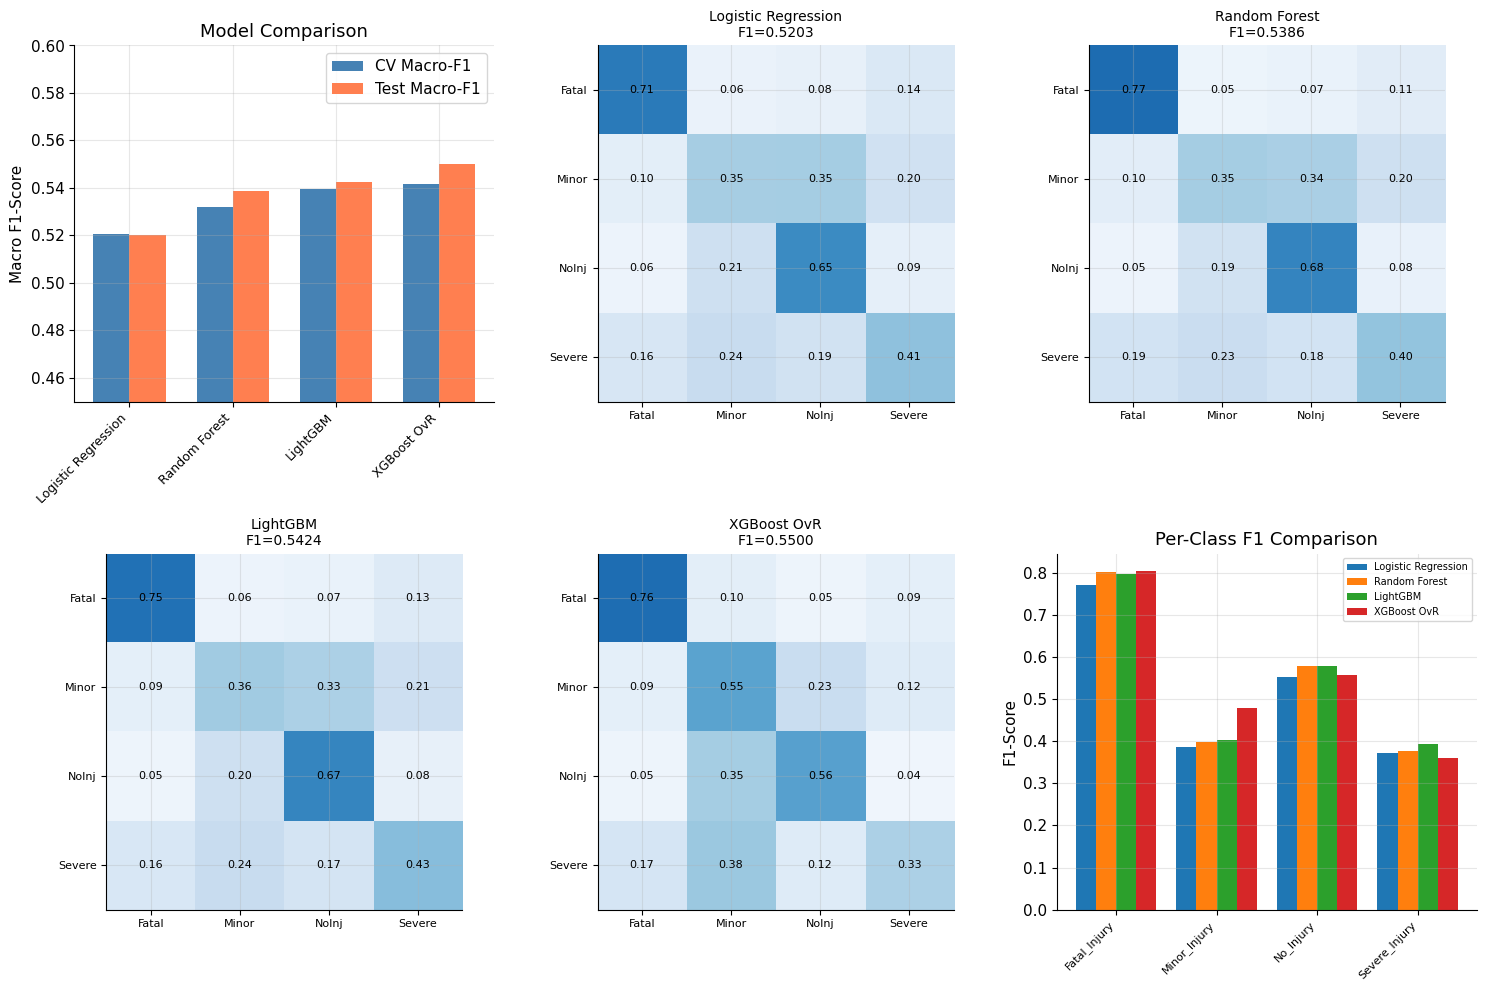

In [45]:
# VISUALISATIONS

print("\n" + "-"*50)
print("VISUALISATIONS")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Model Comparison (Bar)
ax1 = axes[0, 0]
models_names = list(models_results.keys())
cv_means = [models_results[m]['cv_scores'].mean() for m in models_names]
test_f1s = [models_results[m]['test_f1'] for m in models_names]

x = np.arange(len(models_names))
width = 0.35

ax1.bar(x - width/2, cv_means, width, label='CV Macro-F1', color='steelblue')
ax1.bar(x + width/2, test_f1s, width, label='Test Macro-F1', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Macro F1-Score')
ax1.set_title('Model Comparison')
ax1.legend()
ax1.set_ylim(0.45, 0.60)

# Plot 2-5: Confusion Matrices
for idx, (name, data) in enumerate(models_results.items()):
    if idx < 4:
        row = (idx + 1) // 3
        col = (idx + 1) % 3
        ax = axes[row, col]

        cm = confusion_matrix(y_test, data['pred'])
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(['Fatal', 'Minor', 'NoInj', 'Severe'], fontsize=8)
        ax.set_yticklabels(['Fatal', 'Minor', 'NoInj', 'Severe'], fontsize=8)
        ax.set_title(f'{name}\nF1={data["test_f1"]:.4f}', fontsize=10)

        for i in range(4):
            for j in range(4):
                ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center', fontsize=8)

# Plot 6: Per-Class F1 Comparison
ax6 = axes[1, 2]
x = np.arange(4)
width = 0.2

for i, (name, data) in enumerate(models_results.items()):
    f1_scores = f1_score(y_test, data['pred'], average=None)
    ax6.bar(x + i*width, f1_scores, width, label=name)

ax6.set_xticks(x + width*1.5)
ax6.set_xticklabels(encoder.classes_, rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('F1-Score')
ax6.set_title('Per-Class F1 Comparison')
ax6.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Key misclassification patterns:**
- Severe_Injury most confused with Minor_Injury (36%)
- Minor_Injury confused with No_Injury (26%) and Severe (12%)
- Fatal_Injury well-separated from other classes


--------------------------------------------------
10.4 ROC CURVES
--------------------------------------------------


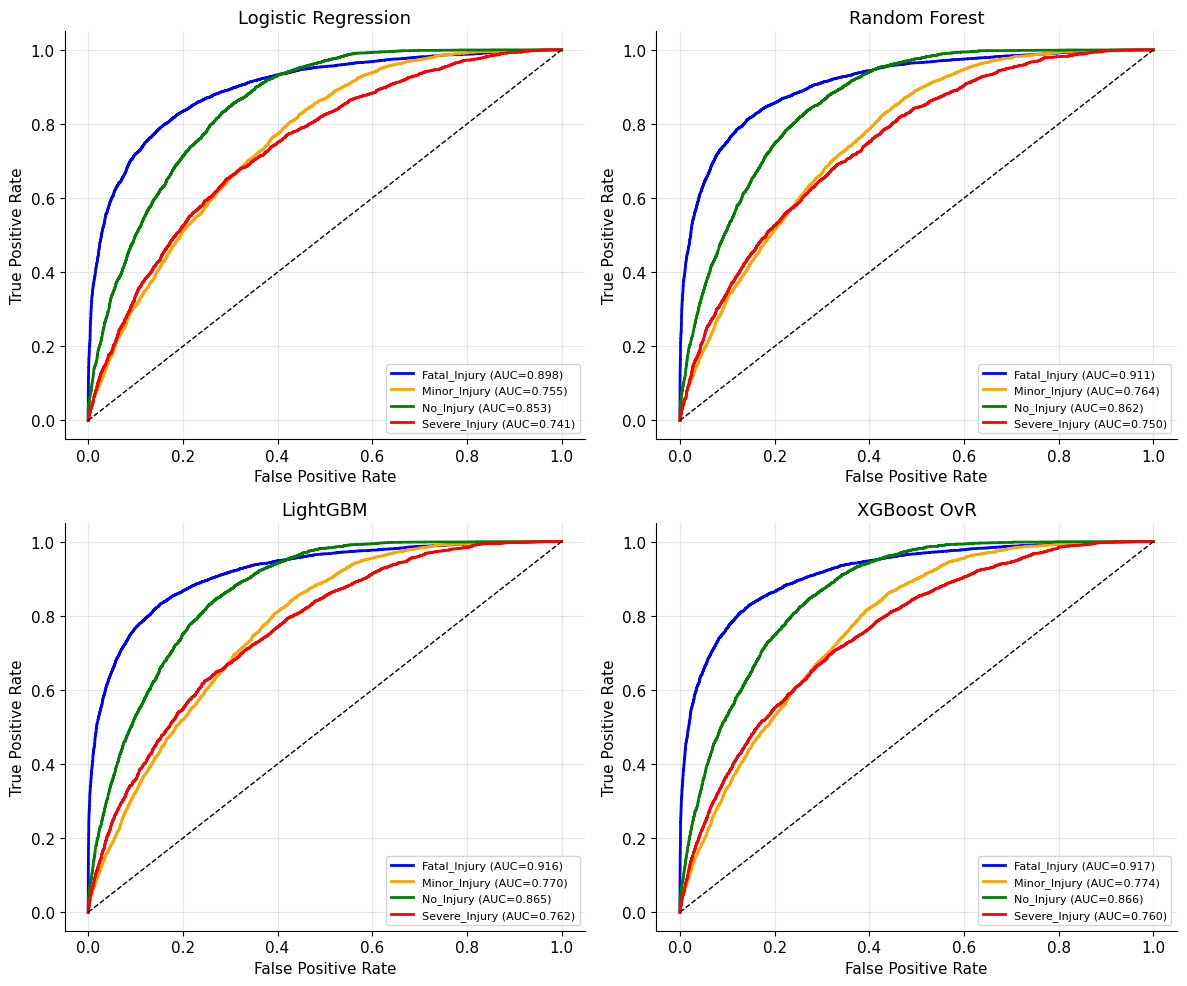

In [46]:
# ROC CURVES

print("\n" + "-"*50)
print("10.4 ROC CURVES")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
colors = ['blue', 'orange', 'green', 'red']

for idx, (name, data) in enumerate(models_results.items()):
    ax = axes[idx]

    for i, (cls, color) in enumerate(zip(encoder.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], data['proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Compare best two models
print("Statistical Significance Testing")
print("="*50)

# Paired t-test between XGBoost OvR and LightGBM
t_stat, p_value = stats.ttest_rel(xgb_cv_scores, lgb_cv_scores)
print(f"\nXGBoost OvR vs LightGBM:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Effect size (Cohen's d)
cohens_d = (np.mean(xgb_cv_scores) - np.mean(lgb_cv_scores)) / np.sqrt(
    (np.std(xgb_cv_scores)**2 + np.std(lgb_cv_scores)**2) / 2
)
print(f"  Cohen's d: {cohens_d:.4f}")

Statistical Significance Testing

XGBoost OvR vs LightGBM:
  t-statistic: 1.5198
  p-value: 0.2032
  Significant at α=0.05: No
  Cohen's d: 1.0453


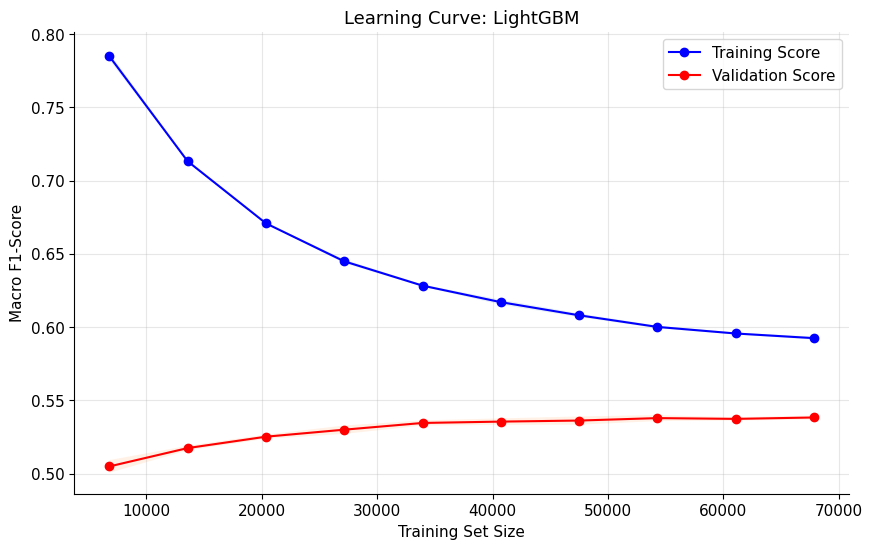

In [50]:
train_sizes, train_scores, val_scores = learning_curve(
    lgb_model, X_train_selected, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring=macro_f1_scorer, n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'b-o', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'r-o', label='Validation Score')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1-Score')
plt.title('Learning Curve: LightGBM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 Learning Curve Analysis

The learning curve for LightGBM shows validation performance plateauing at F1 ~ 0.54 regardless of training set size, while training performance decreases from 0.79 to 0.59. This convergence pattern indicates:

1. **Sufficient data quantity**: Additional samples provide diminishing returns after ~ 40,000 examples
2. **Feature limitations**: The performance ceiling suggests the available features lack sufficient predictive signal for finer injury severity distinctions
3. **Irreducible error**: Some injury outcomes may be inherently unpredictable from the recorded accident characteristics alone

### 3.4 Best Model Configuration

**XGBoost One-vs-Rest** achieved the best overall performance with:

**Stage 1 - Hyperparameters (via BayesSearchCV):**
- n_estimators: 674
- max_depth: 9
- learning_rate: 0.024
- subsample: 1.0
- colsample_bytree: 0.82

**Stage 2 - Class-Specific Boost Multipliers (via Bayesian Optimization):**
- Fatal_Injury: 0.74 (reduced 26%)
- Minor_Injury: 1.11 (boosted 11%)
- No_Injury: 0.70 (reduced 30%)
- Severe_Injury: 0.81 (reduced 19%)

**Stage 3 - Decision Thresholds:**
- All classes: 1.0 (default thresholds, tuning did not improve)

### Summary: Final Pipeline Comparison

| Pipeline | Method | CV Macro-F1 | Test Macro-F1 | Training Time |
|----------|--------|-------------|---------------|---------------|
| Logistic Regression | Baseline | 0.5196 | 0.5203 | 10.5s |
| Random Forest | RandomizedSearchCV | 0.5314 | 0.5386 | 33.6 min |
| LightGBM | RandomizedSearchCV + Weight Tuning | 0.5397 | 0.5424 | 35.6 min |
| **XGBoost OvR** | **BayesSearchCV + Boost Tuning** | **0.5416** | **0.5500** | 72.3 min |

## 4 Discussion

### 4.1 Why Tree-Based Models Outperformed Logistic Regression

The performance gap (F1: 0.5203 → 0.5386-0.5500) is explained by:

1. **Non-linear relationships**: Injury severity depends on complex interactions (e.g., ejection × restraint × age) that linear models cannot capture without manual polynomial expansion

2. **Automatic feature interactions**: Tree models discover combinations like "elderly + no restraint + front seat" automatically through recursive partitioning

3. **Robustness to feature scaling**: Trees are invariant to monotonic transformations, while LR performance depends on proper standardization

### 4.2 Why XGBoost OvR Achieved Best Results

The One-vs-Rest approach with class-specific tuning provided advantages:

1. **Class-specific optimization**: Different boost multipliers allowed the model to allocate more capacity to difficult minority classes (Minor_Injury boosted 11%, Fatal/No_Injury/Severe reduced)

2. **Improved recall for Minor_Injury**: F1 improved from 0.39 to 0.48 (+23.9%), primarily through increased recall (0.35 → 0.55)

3. **Bayesian optimization**: Efficient hyperparameter search found optimal configuration in 69.5 minutes total training time

### 4.3 Why Severe_Injury Remains Difficult to Predict

Severe_Injury consistently showed lowest F1-scores (0.36-0.39):

| Factor | Evidence |
|--------|----------|
| **Feature overlap** | 36% confused with Minor_Injury |
| **Intermediate severity** | Boundaries with Minor and Fatal are ambiguous |
| **Smallest class** | 15.1% of data provides less training signal |
| **Missing information** | Vehicle damage severity (delta-V), medical assessments not available |

### 4.4 Limitations and Future Work

**Data limitations:**
- No vehicle damage information (impact speed, deformation)
- No pre-existing health conditions
- Subjective injury assessment by different officers

**Potential improvements:**
- Ensemble of OvR models with different base learners
- Cost-sensitive learning with asymmetric misclassification penalties
- Hierarchical classification (Fatal vs Non-Fatal first, then subdivide)

### 4.5 Practical Implications

The model is suitable for:
- **Triage prioritization**: Fatal injuries predicted with 80% F1, 92% AUC
- **Risk factor identification**: Feature importance reveals actionable insights (restraint use, ejection prevention)
- **Resource allocation**: Predicting likely severity at accident scenes

Not suitable for:
- Definitive medical diagnosis
- Legal determination of injury severity
- Cases where Severe vs Minor distinction is critical

### 4.6 Key Learnings

1. **Bayesian optimization vs Grid/Random search**: BayesSearchCV found better
   hyperparameters with fewer iterations, but the improvement was marginal
   (CV F1: 0.5388 vs 0.5416)

2. **One-vs-Rest strategy**: Decomposing the multi-class problem allowed
   class-specific tuning, improving Minor_Injury recall from 0.35 to 0.55

3. **Performance ceiling**: All models converged to F1 ≈ 0.52-0.55, suggesting
   the limitation is in the data rather than model capacity

## 5 Conclusion

1. **Best Pipeline**: XGBoost OvR achieved Test Macro-F1 = 0.5500, a 5.7% improvement over baseline

2. **Key Success Factors**: Domain-driven feature engineering (115 features) and class-specific optimization were essential

3. **Performance Ceiling**: All models converged to F1 ≈ 0.52-0.55, indicating data limitations rather than model capacity issues

4. **Recommendation**: For deployment, LightGBM offers the best speed-performance trade-off (F1=0.5424, 35.6 min training)